# Import libraries

In [1]:
# import key libraries and kernel settings
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm
import time
from datetime import date
import matplotlib.lines as mlines

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(".."))

# Load data

In [2]:
from src.loading import load_data # function to import columns without NAs, dropping columns with NAs (unless specified as a 'keep_col')

# -------------------- 3.0 m/s water current data
df_3 = load_data("../data/target_trial_3_2025_11_7.parquet",  keep_col='training_status')
# ------------------- 2.0 m/s water current data
df_2 = load_data("../data/target_trial_2.parquet")
# # drop every row from participant p030 due to corrupted data
df_2 = df_2[df_2['ppid'] != 'p030'].copy()

# combine dfs
df_full = pd.concat([df_2, df_3], ignore_index=True)

In [126]:
print(len(np.unique(df_3['ppid'])))
np.unique(df_3['ppid'])

45


array(['1', 'p002', 'p003', 'p004', 'p005', 'p006', 'p007', 'p009',
       'p010', 'p011', 'p014', 'p015', 'p016', 'p017', 'p018', 'p019',
       'p020', 'p021', 'p023', 'p025', 'p026', 'p027', 'p028', 'p029',
       'p030', 'p031', 'p032', 'p033', 'p034', 'p035', 'p036', 'p037',
       'p038', 'p039', 'p040', 'p041', 'p042', 'p043', 'p044', 'p045',
       'p046', 'p047', 'p048', 'p049', 'p050'], dtype=object)

In [124]:
print(len(np.unique(df_2['ppid'])))
np.unique(df_2['ppid'])

38


array(['p000', 'p003', 'p004', 'p005', 'p006', 'p007', 'p008', 'p009',
       'p010', 'p011', 'p013', 'p014', 'p015', 'p016', 'p017', 'p021',
       'p022', 'p023', 'p024', 'p026', 'p029j', 'p031', 'p032', 'p033',
       'p034', 'p035', 'p036', 'p037', 'p042', 'p043', 'p044', 'p045',
       'p046', 'p047', 'p048', 'p049', 'p050', 'p051'], dtype=object)

# Format df

In [3]:

# add new variables
df_full['lateral_error_x'] = (df_full['min_pos_from_target_x'] - df_full['target_position_x']) 
df_full['depth_error_z'] = (df_full['min_pos_from_target_z'] - df_full['target_position_z']) 

# convert key columns to cm:
from src.convert_to_cm import convert_to_cm # function to convert listed columns into cm

df_labeled = convert_to_cm(df_full,
              cols=[
                    'min_pos_from_target_x',
                    'min_pos_from_target_z',
                    'target_position_x',
                    'target_position_z',
                    'lateral_error_x',
                    'depth_error_z'
                   ])

print('res:', df_labeled['target_position_x'].dtypes) # check

# label ppid by water speed
from src.label_water_speed_ppid import label_water_condtion_ppid 
# function that labels ppid data by the speed condition (i.e., 2.0 or 3.0 m/s) and creates a new ppid_full column
df_labeled = label_water_condtion_ppid(df_labeled, ppid_col='ppid', water_col='water_speed_m_s', selected_speeds=[-3.0,-2.0,0.0]).copy() 


df_labeled['launch_deviation'] = (df_labeled['launch_deviation'] * -1.0).copy()
print(df_labeled['launch_deviation'])

# adjust target label with more readable labels
target_mapping = {
    "p0.6": "R60",
    "p0.3": "R30",
    "neg0.3": "L30",
    "neg0.6": "L60"
}
df_labeled['target_x_label'] = df_labeled['target_x_label'].map(target_mapping).copy() # apply new labels

from src.features import order_targets # orders targets from most negative (L60/-60) to most positive (R60/+60) for plotting purposes
df_labeled['target_position_x'] = order_targets(df_labeled.copy())
df_labeled['target_x_label'] = order_targets(df_labeled.copy())

# signed euclidian distance
df_labeled['signed_euclidean_cm'] = (df_labeled['distance_from_target'] * 100) * np.sign(df_labeled['lateral_error_x_cm'])
print(df_labeled.groupby(['target_hit'])['signed_euclidean_cm'].min())
print(df_labeled.groupby(['target_hit'])['signed_euclidean_cm'].max())

# Generate a less ambiguous label for set_order reflecting the first target pair positions (left, first digit; right, second digit); underscore seperates the second pair
df_labeled['set_order'] = df_labeled['set_order'].cat.rename_categories({
    '1': '63_36',
    '2': '36_63'
}).copy()

# ensures PCA compatibility
df_labeled['water_speed_m_s'] = df_labeled['water_speed_m_s'].replace(0.0, 0.0001).copy()


# add temporal phase label categorical varible
from src.add_phases import label_phases, df_add_phases # function that makes new column representing the phnase of the task based on the upper and lower trial bounds
phases = label_phases() 

df_labeled = df_add_phases(df_labeled, phase_array=phases).copy()

phase_order = [
    'familiarization',
    'baseline', 
    'training_1', 
    'washout_1', 
    'training_2', 
    'washout_2'
]

df_labeled['phase'] = pd.Categorical(
    df_labeled['phase'], 
    categories=phase_order, 
    ordered=True
)


from src.add_cycles import add_cycles # function that adds a cycle/block counter globally and per target
df_labeled = add_cycles(df_labeled,
                       n_trials=4,
                       ppid_col='ppid_full',
                       target_col='target_x_label',
                       ).copy()

# filter out familiarization (i.e, starts with an 'f')
df_nf = df_labeled[~df_labeled['phase'].str.startswith('f')].copy()

# remove trials that do not cross a certain threshold in the z-plane (i.e, trials that did not exceed 70 cm in the z-plane)
from src.cleaning import crossed_threshold # first exclusion criteria, drops 397 trials

# make column checking if ball crossed 70.0 cm on z axis
df_nf['crossed_threshold'] = df_nf.apply(
    lambda row: crossed_threshold(row, col="ball_pos_z", val=0.7), # 70 cm
        axis=1
).copy()

print(df_nf['crossed_threshold'].value_counts()) # check number of failed trials (397 total)


# Make a seperate df without trials that did not cross threshold
df_filt = df_nf[df_nf['crossed_threshold']].copy() # retains rows where crossed_threshold == True

# reduce df to key cols as we do not need all raw data output from Unity
from src.cleaning import extract_key_columns
df_small_filt = extract_key_columns(df_filt).copy()


print(df_small_filt.columns)

res: float64
0        12.833083
1         5.548219
2         5.863291
3        -0.443143
4         3.916917
           ...    
41160    -5.273447
41161     1.938383
41162     2.213391
41163    -3.030887
41164    15.191531
Name: launch_deviation, Length: 41165, dtype: float64
0        R30
1        R60
2        L60
3        L30
4        L30
        ... 
41160    R30
41161    R30
41162    L60
41163    R30
41164    L60
Name: target_x_label, Length: 41165, dtype: category
Categories (4, object): ['L60' < 'L30' < 'R30' < 'R60']
0        R30
1        R60
2        L60
3        L30
4        L30
        ... 
41160    R30
41161    R30
41162    L60
41163    R30
41164    L60
Name: target_x_label, Length: 41165, dtype: category
Categories (4, object): ['L60' < 'L30' < 'R30' < 'R60']
target_hit
False   -148.5813
True      -5.4465
Name: signed_euclidean_cm, dtype: float64
target_hit
False    148.5813
True       5.4019
Name: signed_euclidean_cm, dtype: float64
crossed_threshold
True     39108
False    

# Perturbation State Across Trials (0.0 = OFF / 1.0 = ON)

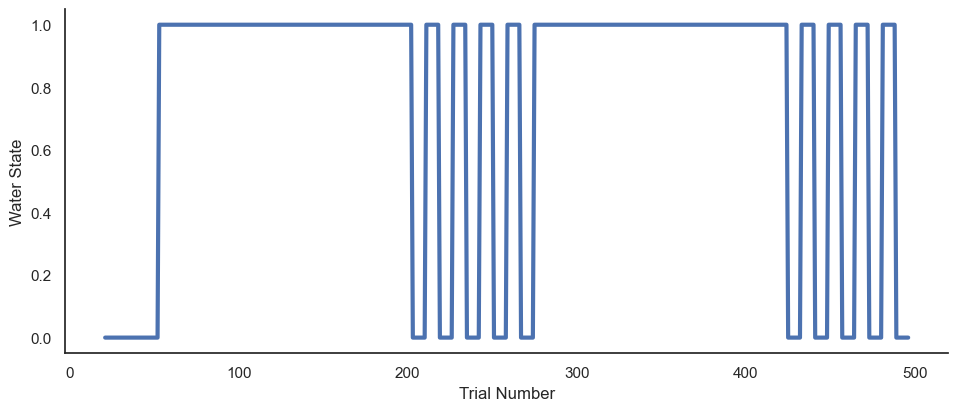

In [123]:
from src.plotting import plot_trial_schedule # function to show the changes in the water current across trials
# trial schedule plot
g = plot_trial_schedule(df_small_filt, context='notebook', font_scale=1, y_col='water_speed_binary')

### **Virtual Environment Parameters**

| Parameter | Symbol | Value | Unit | Description |
| :--- | :---: | :--- | :--- | :--- |
| **Ball Mass** | $m$ | $1.0$ | $\text{kg}$ | Virtual mass of the projectile |
| **Water Density** | $\rho_w$ | $1000.0$ | $\text{kg/m}^3$ | Density of fluid medium |
| **Air Density** | $\rho_a$ | $1.225$ | $\text{kg/m}^3$ | Standard atmospheric density |
| **Drag Coefficient (Water)** | $C_{dw}$ | $0.47$ | - | Coefficient for a spherical object |
| **Drag Coefficient (Air)** | $C_{da}$ | $0.47$ | - | Coefficient for a spherical object |
| **Cross-sectional Area** | $A$ | $78.5398$ | $\text{cm}^2$ | Calculated as $\pi r^2$ ($r = 5.0 \text{ cm}$) |
| **Submersion Ratio** | - | $0.50$ | - | Portion of the ball subject to water drag |
| **Sampling Rate** | $\Delta t$ | $0.01389$ | $\text{s}$ | Physics update frequency ($72\text{ Hz}$) |

### **Lateral Force Calculation**

The water current force applied to the projectile was calculated based on the following equation, incorporating the $50\%$ submersion factor:

$$Waterforce = |S|^2 \frac{1}{2} C_{dw} \rho_w \left( \frac{A}{2} \right)$$

**Where:**
* **$|S|$**: The magnitude of the water speed ($2.0$ or $3.0$ m/s).
* **$C_{dw}$**: Water drag coefficient ($0.47$).
* **$\rho_w$**: Water density ($1000.0$ kg/m³).
* **$A$**: Total cross-sectional area of the ball.
* **$\frac{A}{2}$**: Effective area subject to drag (reflecting $50\%$ submersion).

# Ball Trajectory Data Across Workspace

In [12]:
# from src.extract_full_trajectories import trial_trajectory

# # in meters...

# trial_trajectory(df_small_filt,
#                  x_array='ball_pos_z',
#                  z_array='ball_pos_x',
#                  colour_col='ball_dist_to_center_cm', 
#                  water_col='water_speed_m_s'
#                 )


# Primary Axis of Error

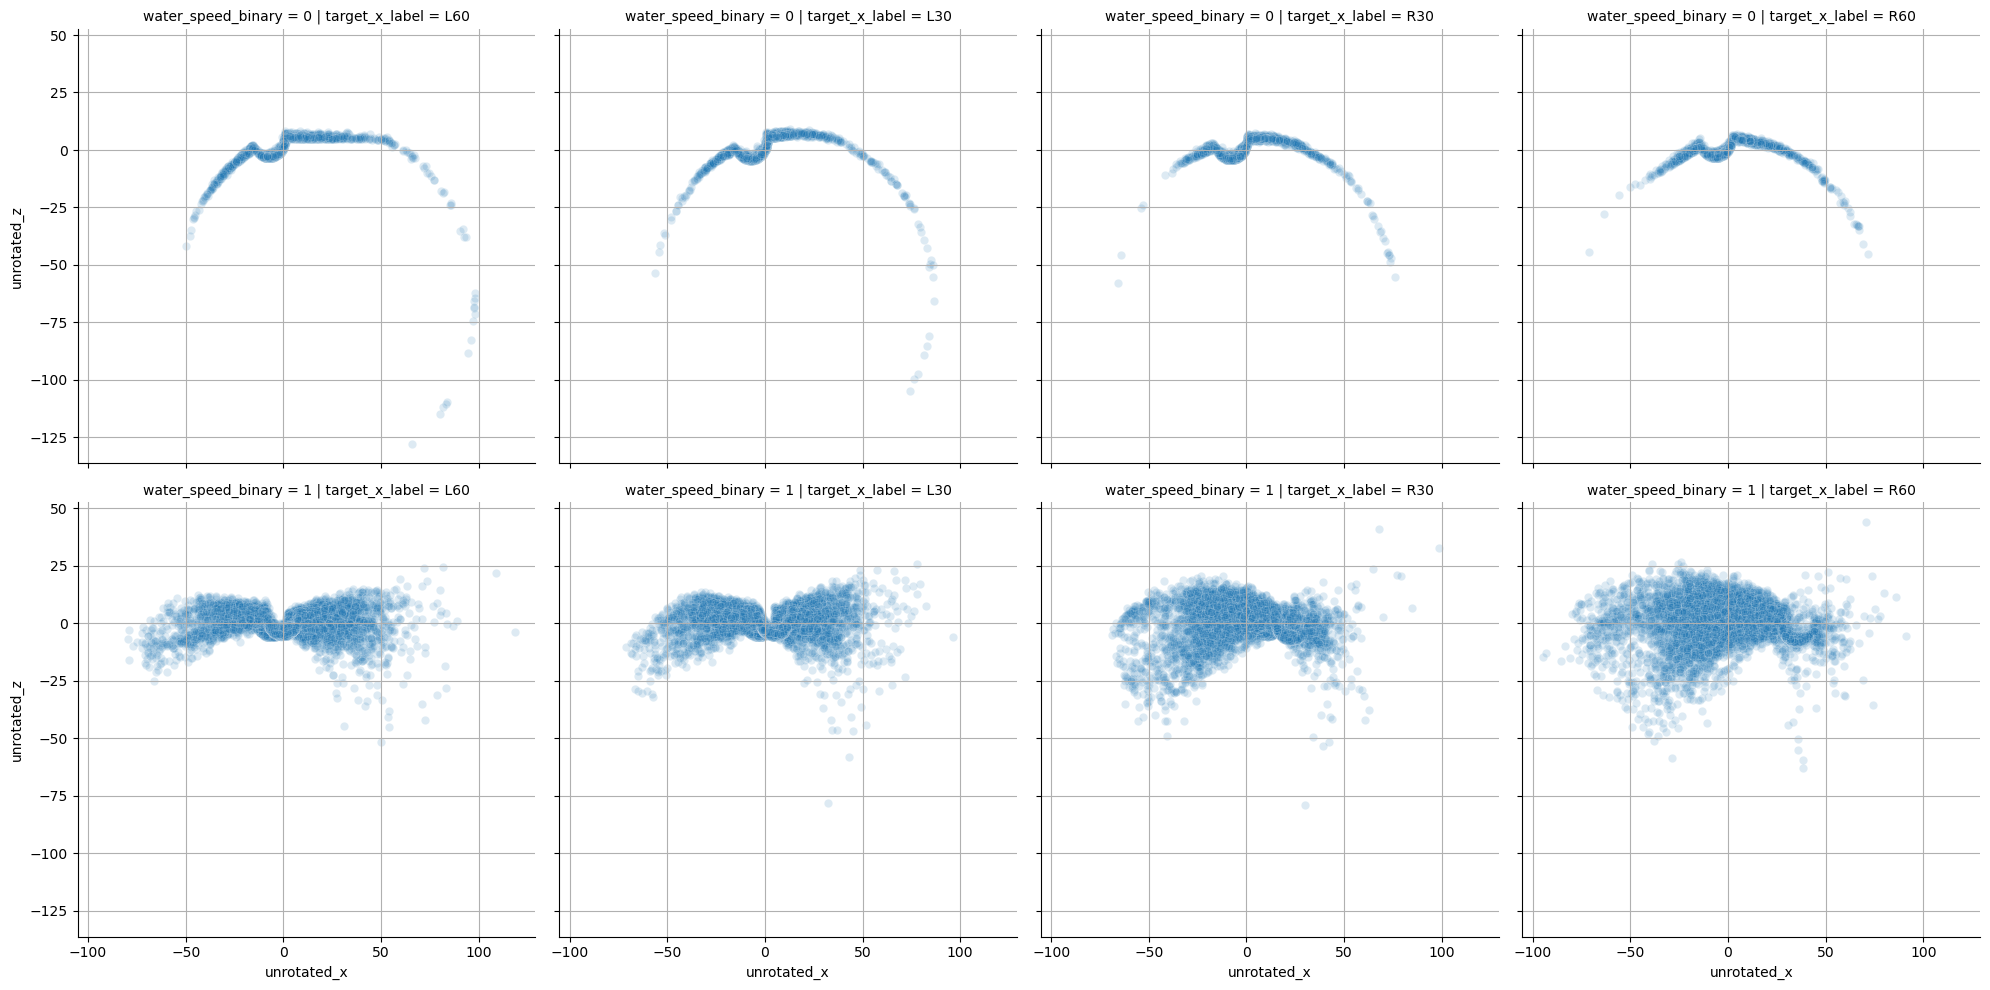

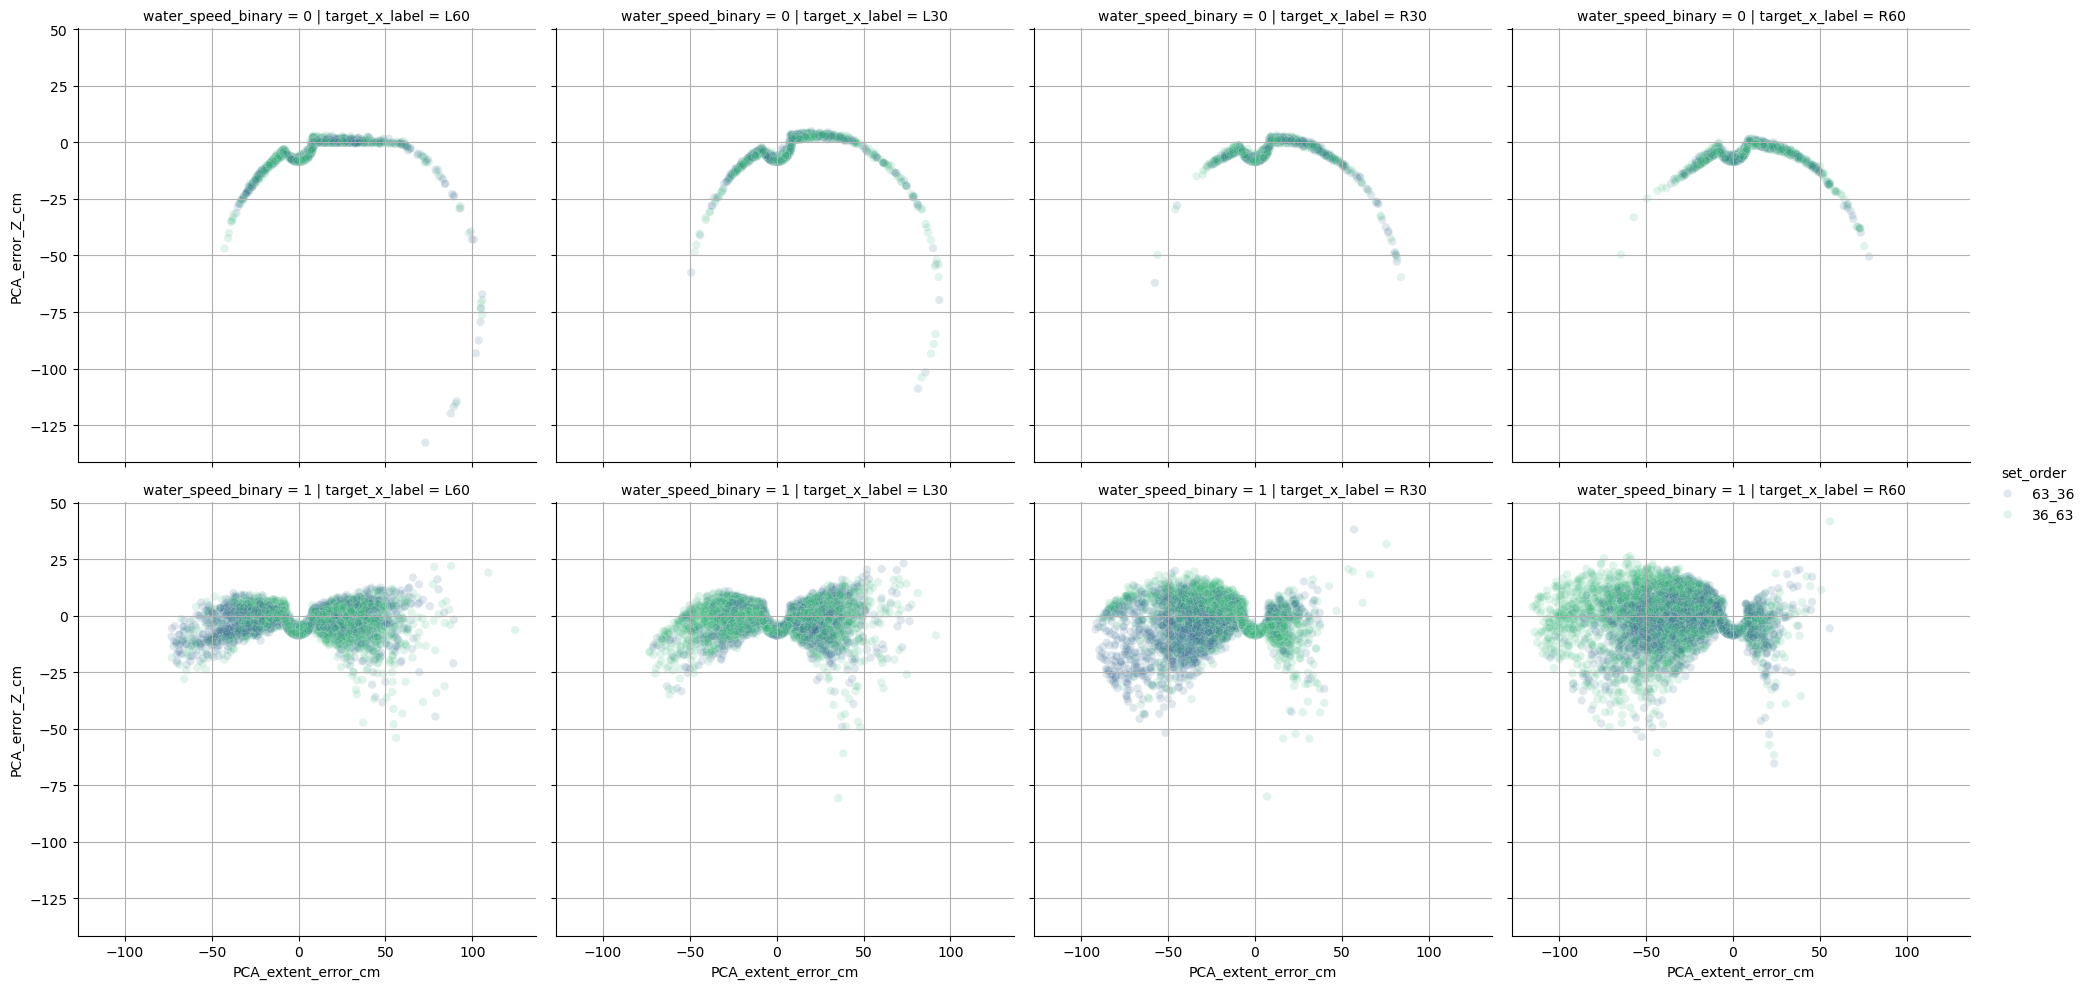

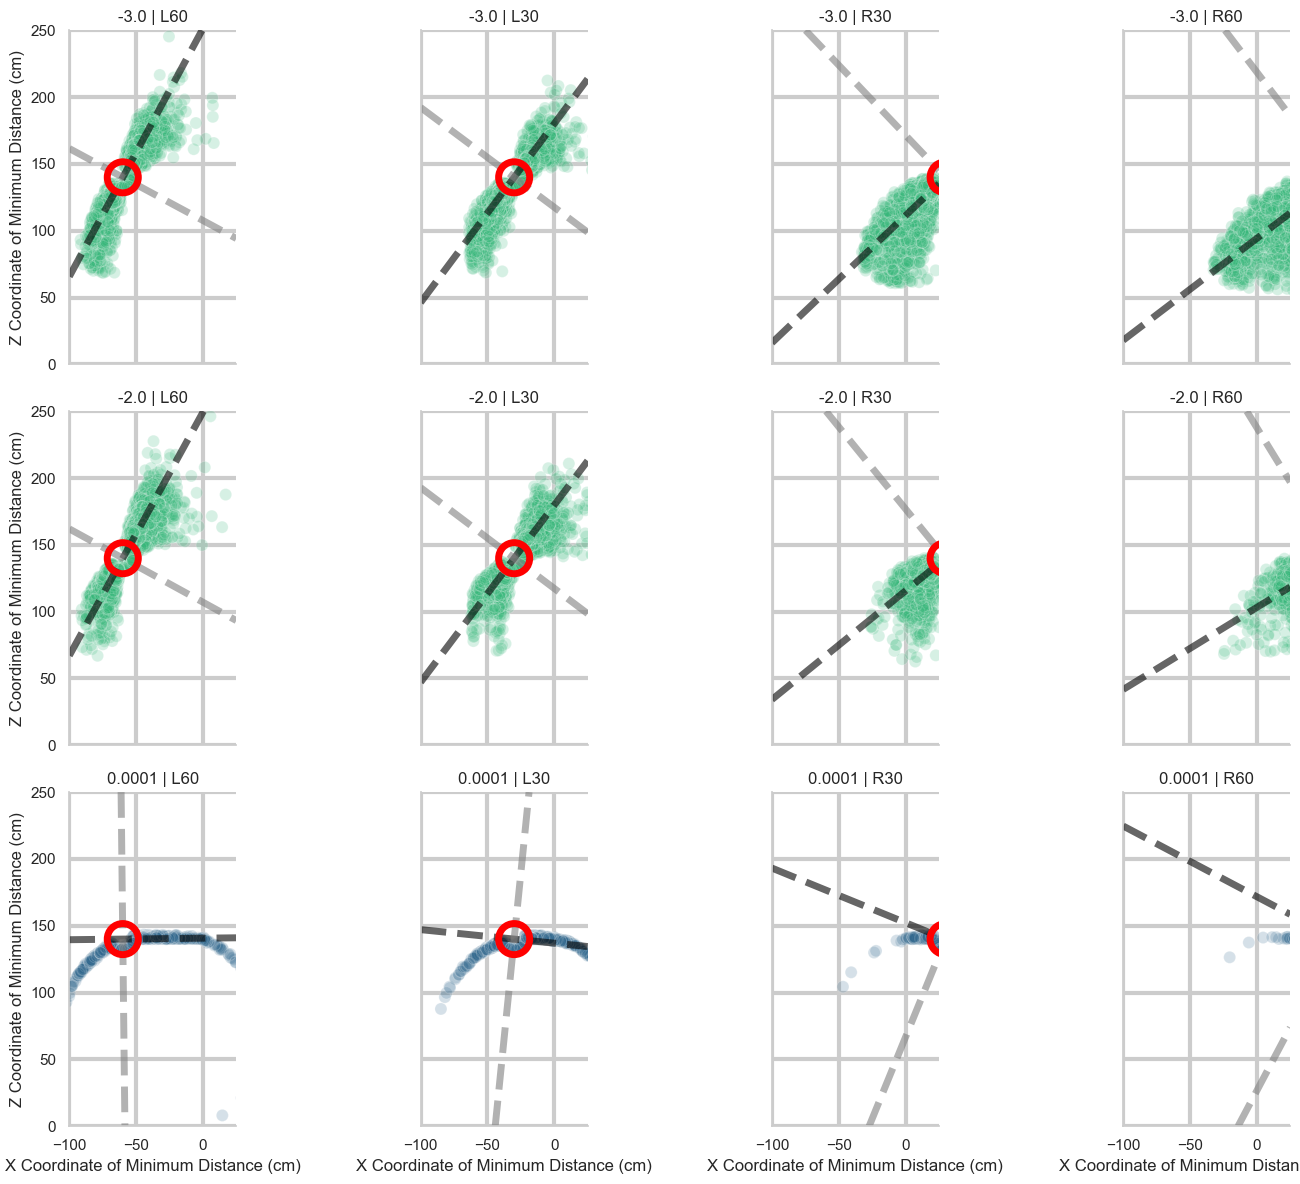

In [7]:
from src.PCA import compute_PCA_summary

features = ['min_pos_from_target_x_cm', 'min_pos_from_target_z_cm']
target_x_col = 'target_position_x_cm'
target_z_col = 'target_position_z_cm'


PCA_table = compute_PCA_summary(df_small_filt,
            features = features,
            group_cols = ['water_speed_m_s','target_position_x_cm'],
            water_col = 'water_speed_m_s',
            n_components=2
            )
PCA_table

# extract relevant columns
PCA_table_small = PCA_table.iloc[:, 0:9].copy()
PCA_table_small


# merge small summary table into raw df with trial-by-trial data
df_angles = df_small_filt.copy()
 
group_cols = ['water_speed_m_s','target_position_x_cm']
new_cols = ['pc_vector_1_angle','pc_vector_1_pca_center_x','pc_vector_1_pca_center_z','pc_vector_1_c_X','pc_vector_1_c_Z']

df_angles_v = df_angles.merge(PCA_table_small[group_cols + new_cols], how="left", on=group_cols)

from src.PCA import compute_PCA_error

PCA_error_df = compute_PCA_error(trial_df=df_angles_v,
                  pc_deg='pc_vector_1_angle',
                  target_x_col=target_x_col,
                  target_z_col=target_z_col,
                  features = features,
                  group_cols = ['water_speed_m_s','target_position_x_cm'],
                  water_col = 'water_speed_m_s',
                  show_plots = True
                 )


from src.plotting import plot_min_x_z

plot_min_x_z(PCA_error_df,
             c_col='target_x_label',
             r_col='water_speed_m_s',
             slope_array=[[61.685831, 53.243388, 43.616088, 37.305211], # 3.0 m/s
                          [61.234584, 52.969086, 39.132036, 31.544813], # 2.0 m/s
                          [0.656367, -5.779064, -22.239128, -27.872954]], # 0.0 m/s
             target_x_array=[-60, -30, 30, 60], 
             show_slopes=True,
             show_orthogonal=True,
             show_target=True,
             x_col_title = 'X Coordinate of Minimum Distance (cm)',
             y_col_title = 'Z Coordinate of Minimum Distance (cm)',
             context='notebook'
            )

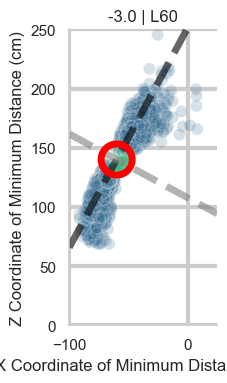

In [151]:
# for illustration, filter ONLY L60
L60_df = PCA_error_df[(PCA_error_df['target_x_label'] == 'L60') & (PCA_error_df['water_speed_m_s'] == -3.0)]

from src.plotting import plot_min_x_z
plot_min_x_z(L60_df,
             c_col='target_x_label',
             r_col='water_speed_m_s',
             slope_array=[[61.685831], # 3.0 m/s
                          [61.234584], # 2.0 m/s
                          [0.656367]], # 0.0 m/s
             hue_col='target_hit',
             target_x_array=[-60], 
             show_slopes=True,
             show_orthogonal=True,
             show_target=True,
             x_col_title = 'X Coordinate of Minimum Distance (cm)',
             y_col_title = 'Z Coordinate of Minimum Distance (cm)',
             context='notebook'
            )

# -100, 50

### Signed Minimum Metric Error

In [9]:

PCA_error_df['min_distance_target_x_cm'] = PCA_error_df['min_pos_from_target_x_cm']-PCA_error_df['target_position_x_cm']
PCA_error_df['min_distance_target_z_cm'] = PCA_error_df['min_pos_from_target_z_cm']-PCA_error_df['target_position_z_cm']

PCA_error_df['flip_min_distance_xPCA'] = np.sqrt(PCA_error_df['min_distance_target_x_cm']**2 + PCA_error_df['min_distance_target_z_cm']**2) * np.sign(PCA_error_df['PCA_extent_error_cm'])*-1

# # # check the signs of the dv
# plot_min_x_z(PCA_error_df,
#              c_col='target_x_label',
#              r_col='water_speed_m_s',
#              hue_col='PCA_sign',
#              show_target=False,
#              x_col_title = 'X Coordinate of Minimum Distance (cm)',
#              y_col_title = 'Z Coordinate of Minimum Distance (cm)',
#              context='notebook'
#             )



# Baseline & Cleaning

Cleaning Baseline outliers: drops trials that are greater than 2.0 SD from the baseline mean

--- Baseline Trial Outlier Removal (flip_min_distance_xPCA) ---
Baseline Mean: -4.7167, SD: 17.6794
SD Threshold: 2.0 (35.3588 units)
Trials removed: 132 / 2654 total baseline trials
PCA_error_df (39108, 52)
clean_df (38976, 52)
hit min None
hit max None


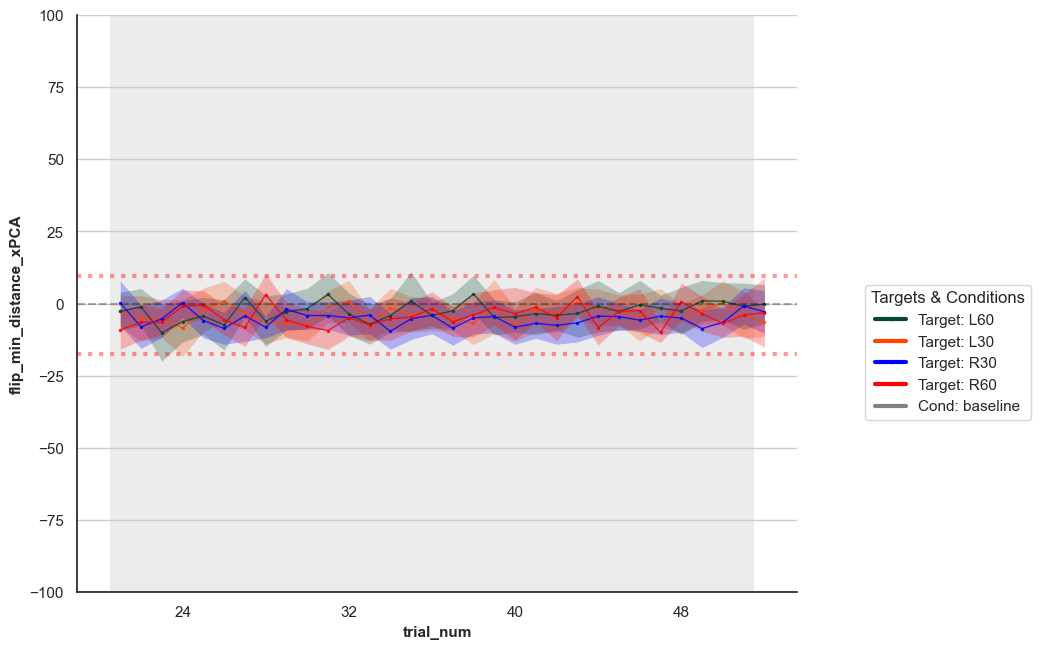

In [11]:
from src.cleaning import remove_baseline_outlier_trials_threshold_sd

# tag baseline outlier ppid
clean_df = remove_baseline_outlier_trials_threshold_sd(PCA_error_df,
                            y_col='flip_min_distance_xPCA',
                            trial_col='trial_num'
                               )

print('PCA_error_df', PCA_error_df.shape)
print('clean_df', clean_df.shape)

from src.plotting import plot_all_trials

df_baseline_clean = clean_df[clean_df['phase'] == 'baseline']

plot_all_trials(df_baseline_clean, 
                     col_col =None,
                     row_col=None,
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'flip_min_distance_xPCA', 
                     x_col='trial_num',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True,
                     show_sd_line=True
                    )




Across ALL trials, remove outliers greater than 3.0 SD

         phase  trial_num  removed_count
0    washout_1        203              1
1    washout_1        204              1
2    washout_1        206              1
3    washout_1        207              1
4    washout_1        220              1
5    washout_1        221              1
6    washout_1        224              1
7    washout_1        225              1
8    washout_1        226              1
9    washout_1        236              1
10   washout_1        237              1
11   washout_1        238              1
12   washout_1        239              1
13   washout_1        242              1
14   washout_1        245              1
15   washout_1        251              2
16   washout_1        252              1
17   washout_1        253              1
18   washout_1        255              1
19   washout_1        257              1
20   washout_1        258              1
21   washout_1        267              1
22   washout_1        268              1
23   washout_1  

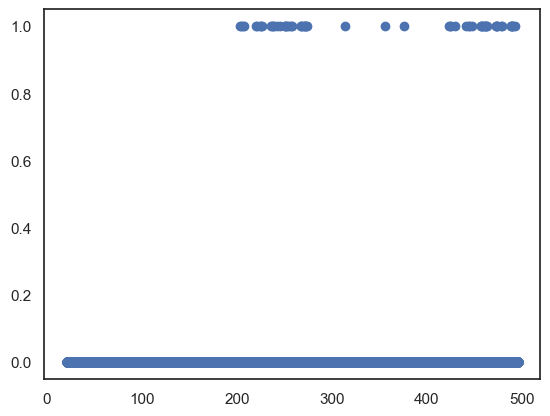

(38914, 53)


In [13]:
from src.cleaning import remove_outliers_per_trial

clean_df_ALL = remove_outliers_per_trial(clean_df,
                              y_col='flip_min_distance_xPCA',
                              trial_col='trial_num',
                              water_col='water_speed_m_s',
                              target_col='target_x_label',
                              phase_col='phase'
                             )

print(clean_df_ALL.shape)

Washout outliers

In [25]:
# from src.washout_outliers import label_outliers_washout

# clean_df_ALL = label_outliers_washout(clean_df_ALL,
#                        phase_col='phase',
#                        water_state_col='water_speed_binary',
#                        threshold_col='flip_min_distance_xPCA',
#                        threshold_val=50.0
#                       )
# clean_df_ALL = clean_df_ALL[clean_df_ALL['is_outlier'] == False].copy()
# print(clean_df_ALL.shape)

(38909, 53)


In [112]:
lwn(np.unique(clean_df_ALL['ppid_full']))

83

# Baseline Correct and Export Preprocessed dfs

In [15]:
# clean_df_ALL = clean_df.copy()
# print(clean_df_ALL.shape)

from src.baseline_correct import baseline_correct

df_bc = baseline_correct(data = clean_df_ALL, #clean_df_ALL
                phase_col = 'phase',
                baseline_string='baseline',
                y_col='launch_deviation',
                PCA_col='flip_min_distance_xPCA'
                ) 

# Extract and join unique experiment strings
exp_tags = "_".join(df_bc['experiment'].unique().astype(str))

# Extract unique water speeds, rounded to prevent floating point noise
speeds = df_bc['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename & save
file_name = f"PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\dual_generalization\\{file_name}"

print(df_bc.columns)
df_bc.to_csv(file_path, index=False)
print(f"Saved: {file_path}")



from src.early_late_exposure import early_late_phase_new

# first and last 4 trials
early_late_phase_df_4 = early_late_phase_new(df = df_bc,
                 group_cols = ['ppid_full','set_order','target_x_label','speed_label'],
                 phase_col = 'phase',
                 phases_to_keep=['training_1','training_2'],
                 trial_col = 'phase_target_trial_num',
                 n_trials = 4
                ).copy()


# first and last 2 trials
early_late_phase_df_2 = early_late_phase_new(df = df_bc,
                 group_cols = ['ppid_full','set_order','target_x_label','speed_label'],
                 phase_col = 'phase',
                 phases_to_keep=['training_1','training_2'],
                 trial_col = 'phase_target_trial_num',
                 n_trials = 2
                ).copy()

# Extract and join unique experiment strings
unique_exps = df_bc['experiment'].unique().astype(str)
exp_tags = "_".join(unique_exps[:2]) 
if len(unique_exps) > 2:
    exp_tags += "_etc"
    
# Extract unique water speeds, rounded to prevent floating point noise
speeds = early_late_phase_df_4['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename & save
file_name_4 = f"early_late_4_phase_PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_name_2 = f"early_late_2_phase_PCA_error_{exp_tags}_speed_{speed_tags}.csv"

file_path_4 = f"..\\data\\dual_generalization\\{file_name_4}"
file_path_2 = f"..\\data\\dual_generalization\\{file_name_2}"

early_late_phase_df_4.to_csv(file_path_4, index=False)
early_late_phase_df_2.to_csv(file_path_2, index=False)

print(f"Saved: {file_path}")

C:\Users\jacob\water_current_MA\src\baseline_correct.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_merged.groupby(['target_x_label'])[f"{y_col}_mean"].mean())


target_x_label
L60    0.465402
L30    1.091486
R30    1.843614
R60    1.509229
Name: launch_deviation_mean, dtype: float64
Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_trial_num', 'phase_target_trial_num', 'trial_num_target',
       'global_cycle_num', 'cycle_target_num', 'cycle_TargetxPhase_num',
       'launch_angle', 'launch_deviation', 'launch_Speed',
       'distance_from_target', 'ball_dist_to_center_cm', 'signed_euclidean_cm',
       'lateral_error_x_cm', 'depth_error_z_cm', 'target_hit',
       'water_speed_binary', 'water_speed_m_s', 'sign_label', 'set_order',
       'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'ball_pos_x', 'ball_pos_z', 'final_ball_pos_x',
       'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 

C:\Users\jacob\water_current_MA\src\early_late_exposure.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby(group_cols + [phase_col])
C:\Users\jacob\water_current_MA\src\early_late_exposure.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby(group_cols + [phase_col])


Saved: ..\data\dual_generalization\PCA_error_projectile_experiment _S1-projectile_experiment_S2-projectile_experiment_S1_3.0M-projectile_experiment 1_S2_3.0M-projectile_experiment 1_speed_neg3_0_neg2_0_0_0.csv


Baseline correction

52
hit min None
hit max None


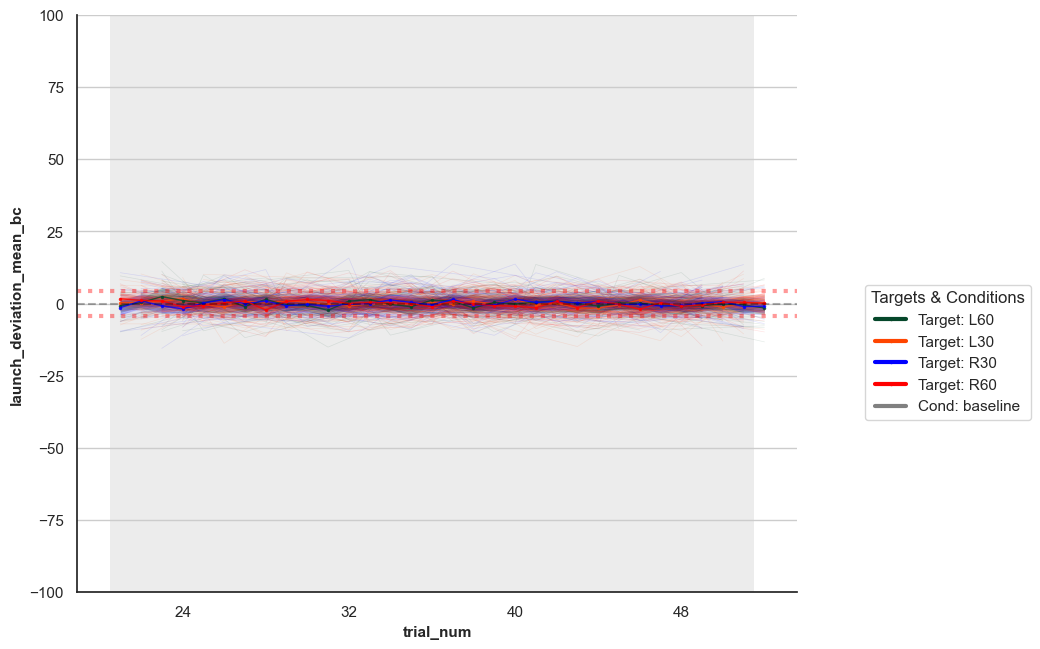

In [21]:
from src.plotting import plot_all_trials

df_bc_baseline = df_bc[df_bc['phase'] == 'baseline']
print(df_bc_baseline['trial_num'].max())

plot_all_trials(df_bc_baseline, 
                     col_col =None,
                     row_col=None,
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_deviation_mean_bc', 
                     x_col='trial_num',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True,
                     show_sd_line=True
                    )




In [23]:
df_bc_baseline.groupby(['target_x_label', 'speed_label'])['launch_deviation'].mean()

C:\Users\jacob\AppData\Local\Temp\ipykernel_13152\1376039442.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_bc_baseline.groupby(['target_x_label', 'speed_label'])['launch_deviation'].mean()


target_x_label  speed_label
L60             -3.0           0.377062
                -2.0           0.420308
L30             -3.0           1.126446
                -2.0           0.849550
R30             -3.0           1.228980
                -2.0           2.458658
R60             -3.0           1.107851
                -2.0           1.901642
Name: launch_deviation, dtype: float64

# Plot all trials

Extent Error

In [51]:
print(df_bc[df_bc['target_hit'] == 'True']['signed_euclidean_cm'].unique())

[-0.      5.0182  5.191  -5.115   5.0556  5.1164 -5.4465  5.4019  5.0774
  5.0063  5.1948  5.1785 -5.0651 -5.0204 -5.2574  5.104  -5.1915  5.0395
 -5.0564  5.1557 -5.0127  5.2016]


C:\Users\jacob\AppData\Local\Temp\ipykernel_9448\1829623672.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_bc.groupby(['phase'])['trial_num'].agg(['min','max']))


                   min    max
phase                        
familiarization    NaN    NaN
baseline          21.0   52.0
training_1        53.0  202.0
washout_1        203.0  274.0
training_2       275.0  424.0
washout_2        425.0  496.0
hit min -5.4465
hit max 5.4018999999999995


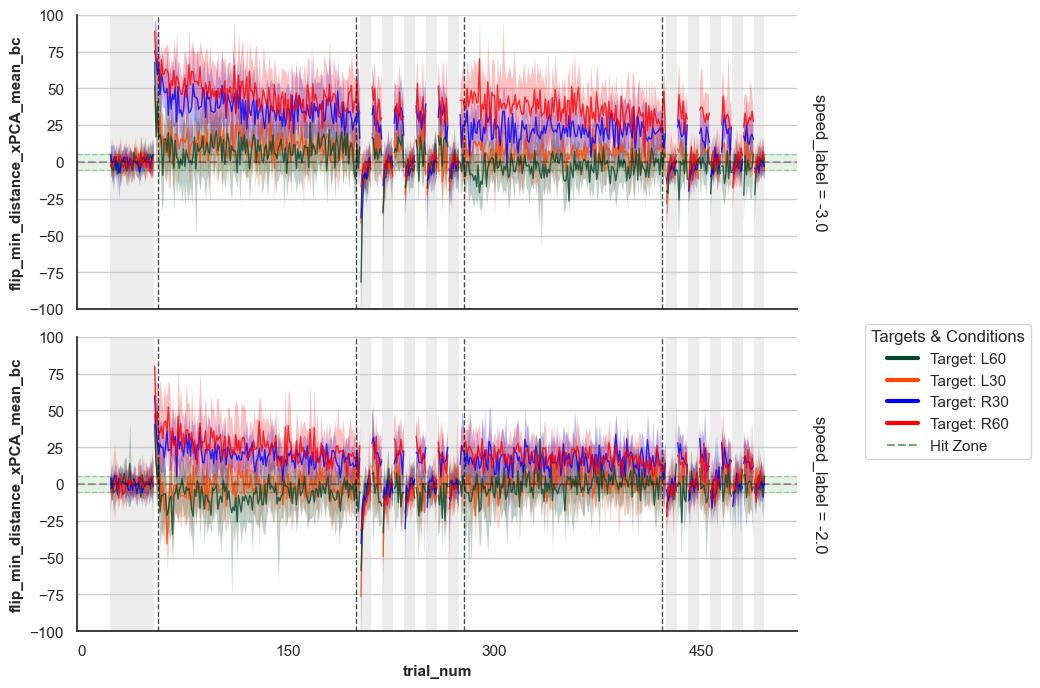

In [25]:
from src.plotting import plot_all_trials

print(df_bc.groupby(['phase'])['trial_num'].agg(['min','max']))

plot_all_trials(df_bc, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'flip_min_distance_xPCA_mean_bc', # 
                     x_col='trial_num',
                     vertical_list=[55.5,199.5, 277.5,421.5],
                     hit_col='target_hit',
                     ref_range_col='signed_euclidean_cm',
                     no_connect_col='phase',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True
                    )                    

Launch Deviation (degrees: relative to target)

hit min None
hit max None


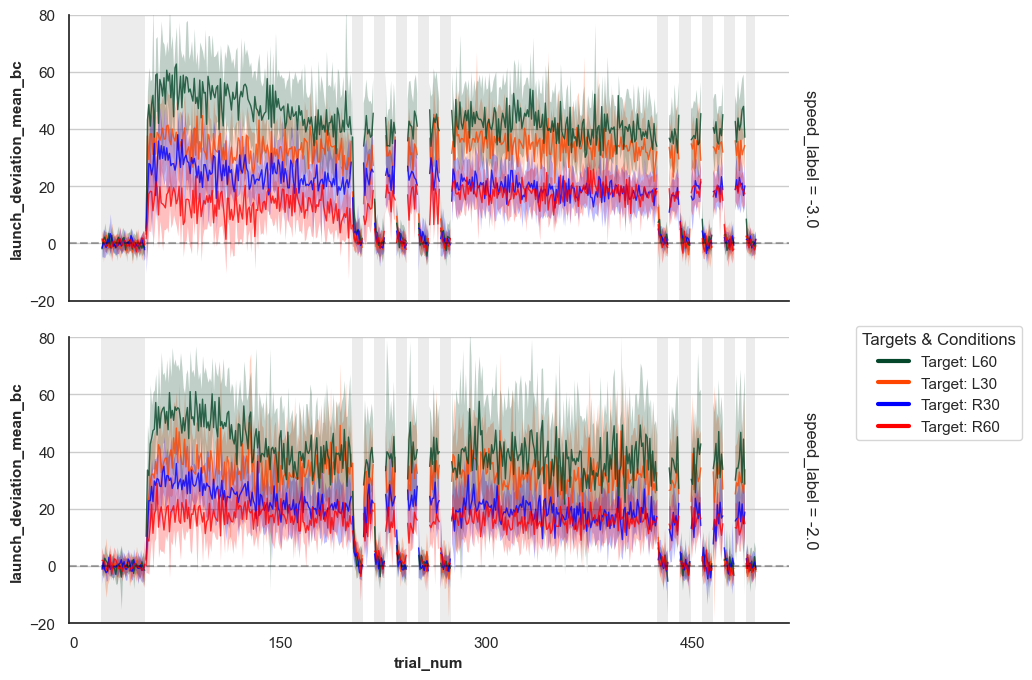

In [27]:
from src.plotting import plot_all_trials

plot_all_trials(df_bc, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_deviation_mean_bc', # 
                     x_col='trial_num',
                     vertical_list= None,
                     hit_col='target_hit',
                     ref_range_col=None,
                     no_connect_col='phase',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     marker_size=0.0,
                     estimator='mean',
                     y_lim=(-20,80),
                     show_zero_line=True
                    )                    

Launch Speed (m/s)

hit min None
hit max None


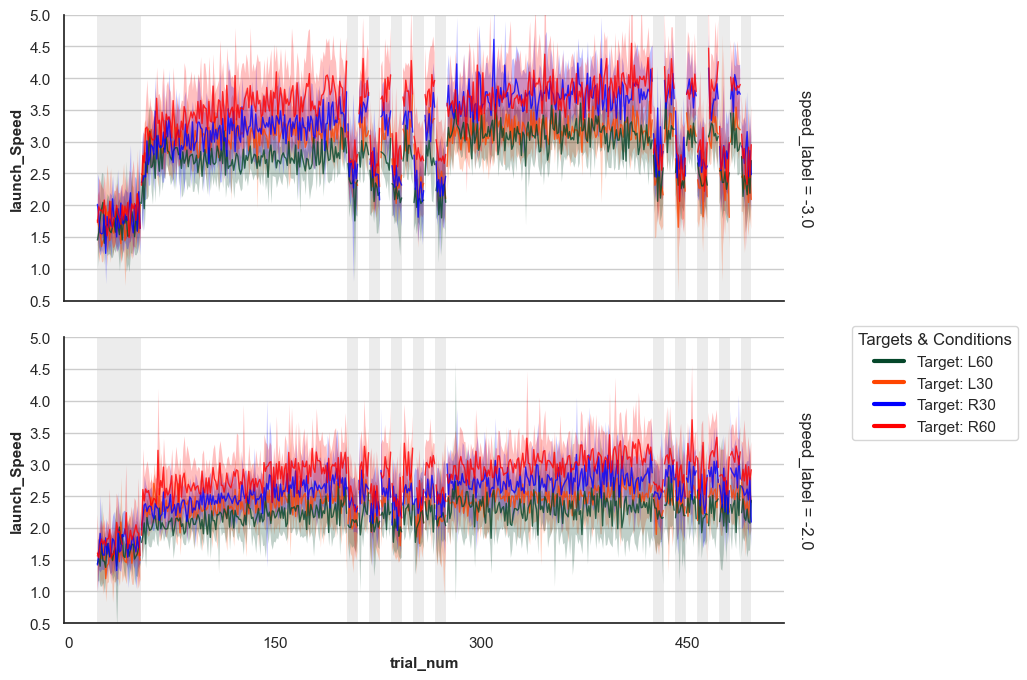

In [29]:
from src.plotting import plot_all_trials

plot_all_trials(df_bc, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_Speed', # 
                     x_col='trial_num',
                     vertical_list= None,
                     hit_col='target_hit',
                     ref_range_col=None,
                     no_connect_col='phase',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     marker_size=0.0,
                     estimator='mean',
                     y_lim=(0.5,5.0),
                     show_zero_line=True
                    )                    

First and Last 4 trials - Training Phase 1

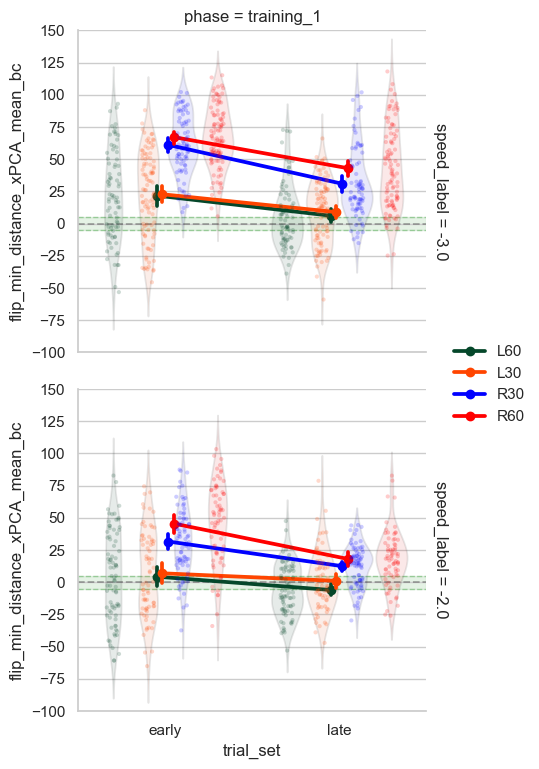

In [88]:
early_late_phase_df_4_t1 = early_late_phase_df_4[early_late_phase_df_4['phase'] == "training_1"]

from src.plotting import plot_slopes
plot_slopes(early_late_phase_df_4_t1,
                         x_col='trial_set',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col='phase',
                         facet_row= 'speed_label'
                            )



First and Last 4 trials - Training Phase 2

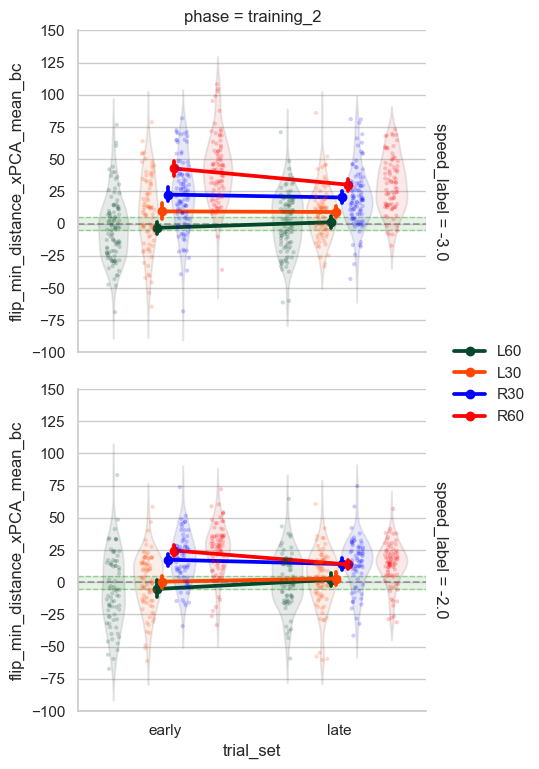

In [19]:
early_late_phase_df_4_t2 = early_late_phase_df_4[early_late_phase_df_4['phase'] == "training_2"]

from src.plotting import plot_slopes
plot_slopes(early_late_phase_df_4_t2,
                         x_col='trial_set',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col='phase',
                         facet_row= 'speed_label'
                            )



First and Last 2 trials - Training Phase 1

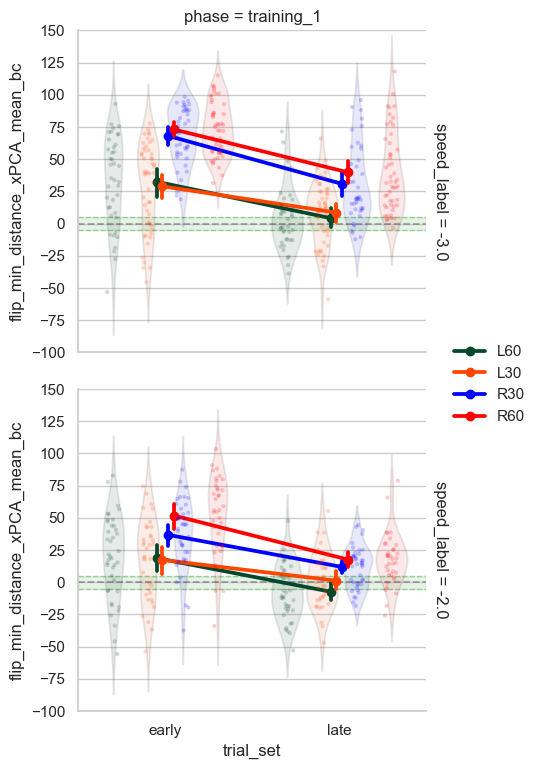

In [21]:
from src.plotting import plot_slopes

early_late_phase_df_2_t1 = early_late_phase_df_2[early_late_phase_df_2['phase'] == "training_1"]

plot_slopes(early_late_phase_df_2_t1,
                         x_col='trial_set',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col='phase',
                         facet_row= 'speed_label'
                            )



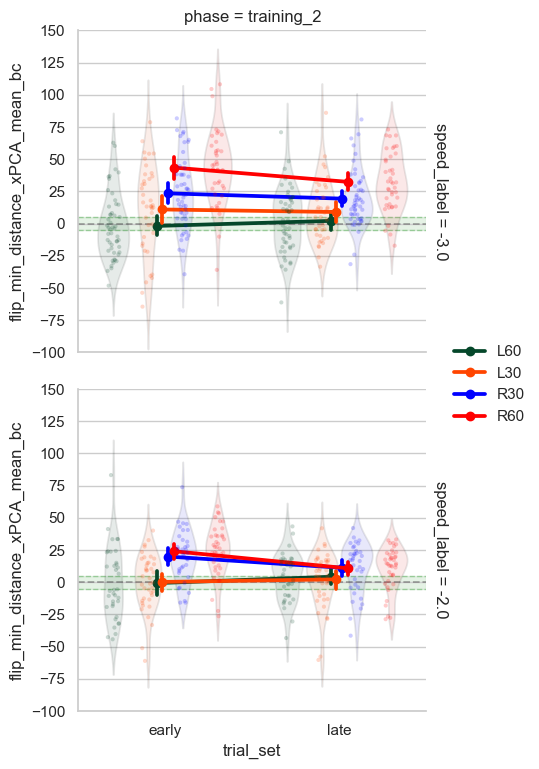

In [21]:
from src.plotting import plot_slopes

early_late_phase_df_2_t2 = early_late_phase_df_2[early_late_phase_df_2['phase'] == "training_2"]

plot_slopes(early_late_phase_df_2_t2,
                         x_col='trial_set',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col='phase',
                         facet_row= 'speed_label'
                            )


# Between-Subjects Transfer

First 4 trials of T1 (*Naive*) vs First 4 trials of T2 (*Experienced*) on the SAME target

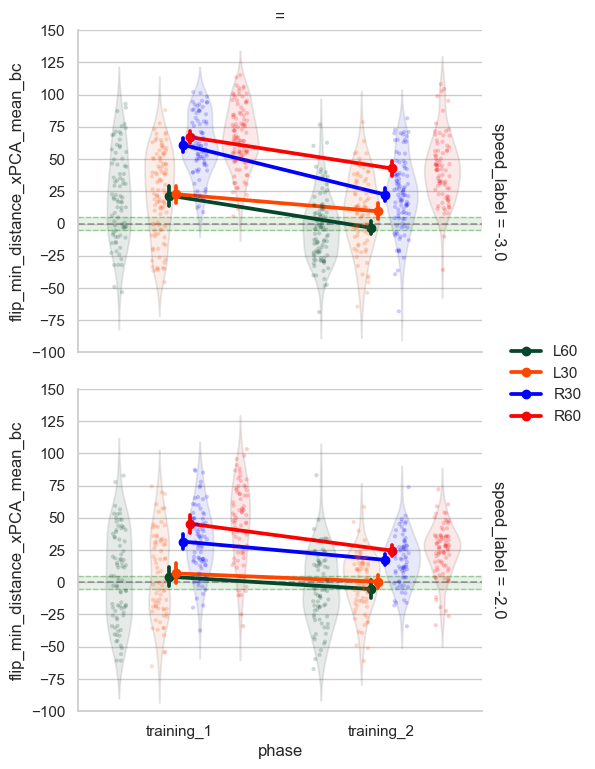

In [87]:

early_df_4 = early_late_phase_df_4[early_late_phase_df_4['trial_set'] == 'early'].copy()
early_df_4['phase'] = early_df_4['phase'].astype(str) # for plotting
   


from src.plotting import plot_slopes
plot_slopes(early_df_4,
                         x_col='phase',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col=None,
                         facet_row='speed_label',
                         facet_aspect=1.0
            
                            )



In [43]:
print(early_df_4.groupby(['ppid_full','phase','target_x_label'])['trial_num'].count().head(20))
print(early_df_4.groupby(['ppid_full','phase','target_x_label'])['trial_num'].count().head(20))





ppid_full  phase       target_x_label
1_neg3     training_1  L60               4
                       L30               0
                       R30               4
                       R60               0
           training_2  L60               0
                       L30               4
                       R30               0
                       R60               4
p000_neg2  training_1  L60               4
                       L30               0
                       R30               4
                       R60               0
           training_2  L60               0
                       L30               4
                       R30               0
                       R60               4
p002_neg3  training_1  L60               0
                       L30               4
                       R30               0
                       R60               4
Name: trial_num, dtype: int64
ppid_full  phase       target_x_label
1_neg3     training_1  L60        

C:\Users\jacob\AppData\Local\Temp\ipykernel_16028\462375389.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(early_df_4.groupby(['ppid_full','phase','target_x_label'])['trial_num'].count().head(20))
C:\Users\jacob\AppData\Local\Temp\ipykernel_16028\462375389.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(early_df_4.groupby(['ppid_full','phase','target_x_label'])['trial_num'].count().head(20))


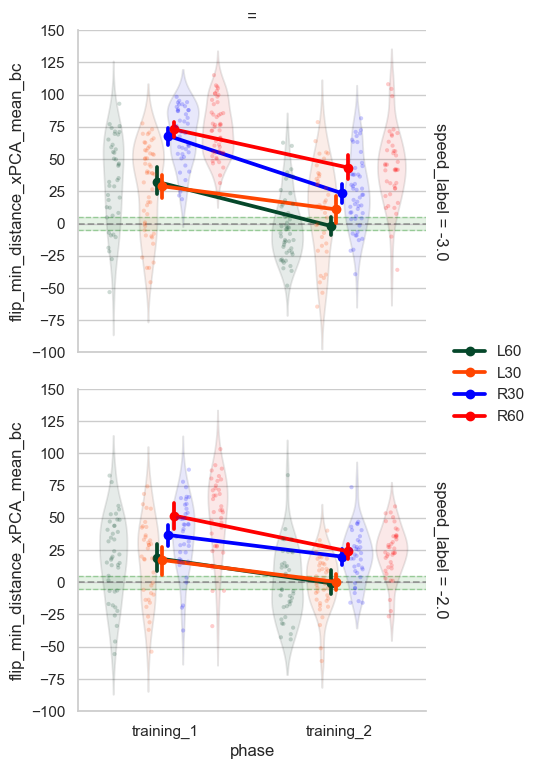

In [91]:

early_df_2 = early_late_phase_df_2[early_late_phase_df_2['trial_set'] == 'early'].copy()
early_df_2['phase'] = early_df_2['phase'].astype(str) # for plotting

from src.plotting import plot_slopes
plot_slopes(early_df_2,
                         x_col='phase',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col=None,
                         facet_row='speed_label'            
                            )



# Washout

Bootstrapped confidence intervals of extent error for first trial per washout cycle

Saved: ..\data\dual_generalization\['washout_1', 'washout_2']_projectile_experiment _S1-projectile_experiment_etc_speed_0.csv


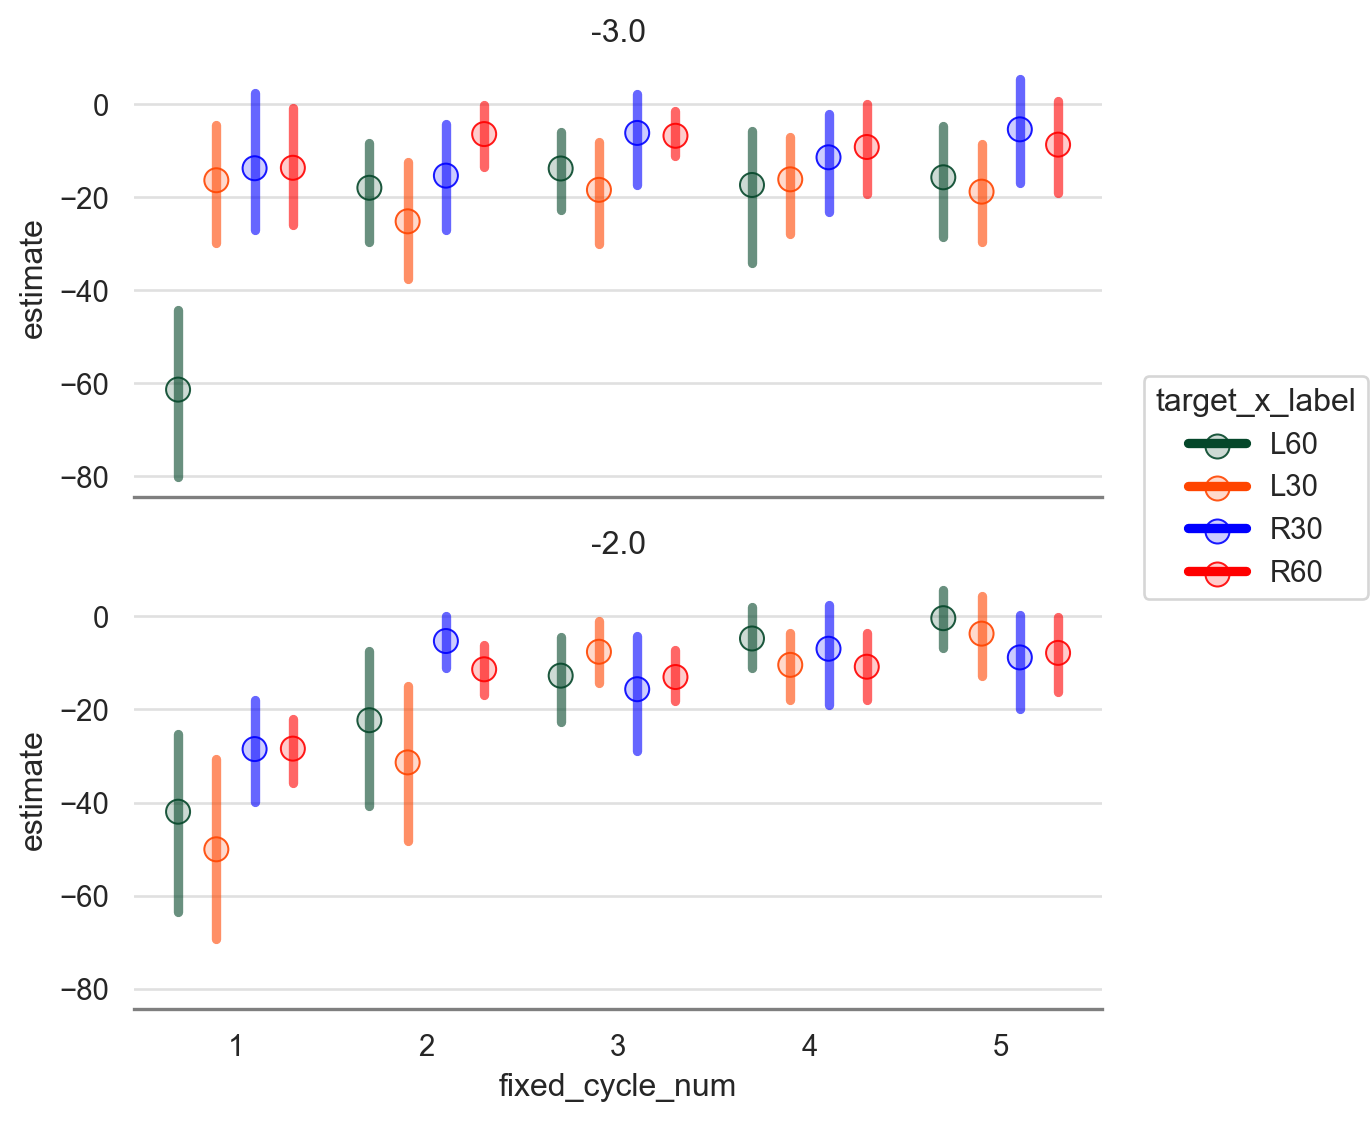

In [97]:
from src.baseline_washout import retain_baseline_washout

df_washout = retain_baseline_washout(df_bc,
                           phase_col='phase',
                           experiment_type ='dual_generalization',
                           phases_to_keep = ['washout_1','washout_2'],
                           experiment_col = 'experiment',
                           water_col = 'water_speed_binary',
                            trial_counter=True)




from src.bootstrap import bootstrap_by_groups, plot_bootstrap_cis
from src.plotting import plot_all_trials_scatter_with_slope

df_washout_p1 = df_washout[df_washout['phase'] == 'washout_1'].copy()

# map early/late
trials_to_keep = [1, 4, 5, 8, 9, 12, 13, 16, 17, 20]
early_late = ['early','late','early','late','early','late','early','late','early','late']
trial_to_rm = dict(zip(trials_to_keep, early_late))
df_washout_p1["early_late"] = df_washout_p1["washout_target_trial_num"].map(trial_to_rm)


df_washout_p1['fixed_cycle_num'] = df_washout_p1['cycle_TargetxPhase_num'].rank(method='dense').astype(int)



df_washout_p1_early = df_washout_p1[df_washout_p1['early_late'] == 'early'].copy()

washout_bootstrap_df = bootstrap_by_groups(df_washout_p1_early,
                          group_cols=['target_x_label','speed_label'],
                          y_col='flip_min_distance_xPCA_mean_bc',
                          x_col='fixed_cycle_num'
                         )


plot_bootstrap_cis(washout_bootstrap_df,
                   x_col='fixed_cycle_num',
                   facet_row='speed_label',
                   hue='target_x_label'
                  )    

In [65]:
print(df_washout_p1.columns)

t = df_washout_p1.sort_values(by=['ppid_full','fixed_cycle_num']).groupby(['ppid_full', 'fixed_cycle_num','target_position_x_cm']).head(2)

print(t[['ppid_full', 'target_position_x_cm', 'washout_target_trial_num','fixed_cycle_num']].head(25))


Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_trial_num', 'phase_target_trial_num', 'trial_num_target',
       'global_cycle_num', 'cycle_target_num', 'cycle_TargetxPhase_num',
       'launch_angle', 'launch_deviation', 'launch_Speed',
       'distance_from_target', 'ball_dist_to_center_cm', 'signed_euclidean_cm',
       'lateral_error_x_cm', 'depth_error_z_cm', 'target_hit',
       'water_speed_binary', 'water_speed_m_s', 'sign_label', 'set_order',
       'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'ball_pos_x', 'ball_pos_z', 'final_ball_pos_x',
       'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unrotated_z', 'PCA_

C:\Users\jacob\AppData\Local\Temp\ipykernel_18300\470970381.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t = df_washout_p1.sort_values(by=['ppid_full','fixed_cycle_num']).groupby(['ppid_full', 'fixed_cycle_num','target_position_x_cm']).head(2)


In [147]:
df_c[['global_cycle_num','trial_num','target_x_label','water_speed_binary']].head(80)

,global_cycle_num,trial_num,target_x_label,water_speed_binary
159,47,186,R30,1
160,47,187,L60,1
161,47,188,R30,1
162,48,189,R30,1
163,48,190,L60,1
...,...,...,...,...
2020,49,194,R60,1
2021,49,195,L30,1
2022,49,196,R60,1
2023,50,197,L30,1


hit min -5.2574000000000005
hit max 5.4018999999999995


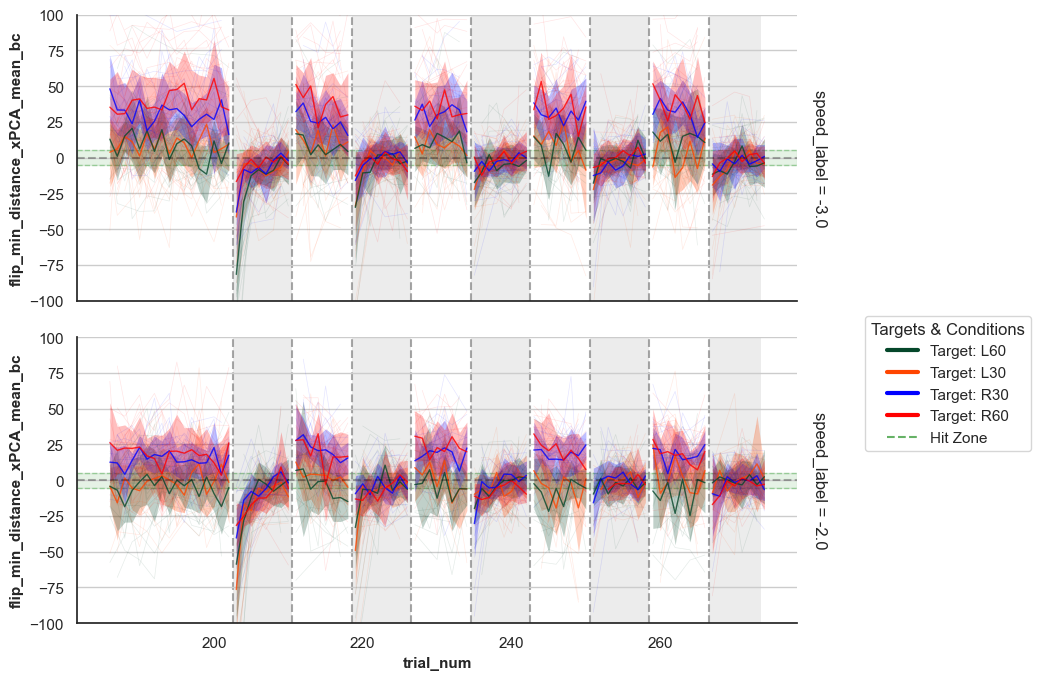

In [37]:
df_t1 = df_bc[df_bc['phase'] == 'training_1']
trial_max = df_t1['trial_num'].max()

df_t1_last16 = df_t1[df_t1['trial_num'] >= trial_max - 16]

# washout 1 only
df_w1 = df_bc[df_bc['phase'] == 'washout_1'].copy()

# early washout 2
df_w2 = df_bc[df_bc['phase'] == 'washout_2'].copy()


# # combine
df_c = pd.concat([df_t1_last16, df_w1])

from src.plotting import plot_all_trials
plot_all_trials(df_c, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'flip_min_distance_xPCA_mean_bc', # launch_deviation_mean_bc
                     x_col='trial_num',
                     vertical_list=[],
                     hit_col='target_hit',
                     ref_range_col='signed_euclidean_cm',
                     no_connect_col=['phase','water_speed_binary'],
                     context='notebook', 
                     transition_col='water_speed_binary',
                     marker_size=0.0,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True
                    )                    

hit min -5.4465
hit max 5.1948


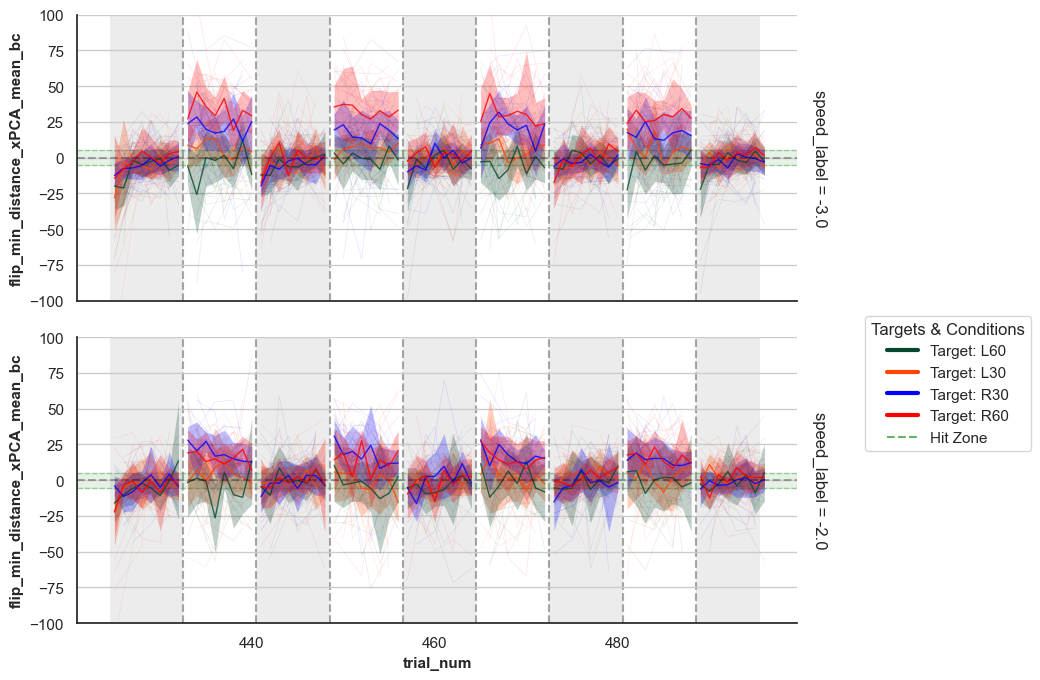

In [35]:
from src.plotting import plot_all_trials
plot_all_trials(df_w2, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'flip_min_distance_xPCA_mean_bc', # launch_deviation_mean_bc
                     x_col='trial_num',
                     vertical_list=[],
                     hit_col='target_hit',
                     ref_range_col='signed_euclidean_cm',
                     no_connect_col=['phase','water_speed_binary'],
                     context='notebook', 
                     transition_col='water_speed_binary',
                     marker_size=0.0,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True
                    )            

In [47]:
df_w1_0 = df_w1[df_w1['water_speed_binary'] == 0.0]
# Extract as a list of trial numbers
trial_numbers = df_w1_0.loc[df_w1_0['flip_min_distance_xPCA_mean_bc'] > 50.0, 'trial_num'].tolist()
print(trial_numbers)

[209, 203, 223, 252, 257, 241]


In [375]:
df_bc['launch_deviation']

0        -0.980091
1         6.044347
2         2.092893
3        -0.181509
4         2.379829
           ...    
38909    -5.273447
38910     1.938383
38911     2.213391
38912    -3.030887
38913    15.191531
Name: launch_deviation, Length: 38914, dtype: float64

In [45]:
df_baseline = df_bc[df_bc['phase'] == 'baseline']
max_trials = df_baseline['trial_num'].max()

# grab last 8 trials of baseline 
df_baseline_last8 = df_baseline[df_baseline['trial_num'] >= max_trials - 8]
#print(df_baseline_last8['trial_num'].min())


# plot_all_trials(df_baseline_last8, 
#                      col_col =None,
#                      row_col='speed_label',
#                      cond_col=None,
#                      ppid_col='ppid_full',
#                      target_col='target_x_label',
#                      y_col = 'launch_deviation', # 
#                      x_col='trial_num',
#                      vertical_list=[],
#                      hit_col='target_hit',
#                      ref_range_col=None,
#                      no_connect_col='phase',
#                      context='notebook', 
#                      transition_col='water_speed_binary',
#                      marker_size=2.5,
#                      estimator='mean',
#                      y_lim=(-10,10),
#                      show_zero_line=True
#                     )           


from src.bootstrap import run_bootstrap

all_targets_CIs = run_bootstrap(df_baseline_last8, 
              y_col=['launch_deviation_mean_bc']
                       )
print("ALL targets:\n\n", all_targets_CIs)

per_targets_CIs = run_bootstrap(df_baseline_last8, 
              y_col=['launch_deviation_mean_bc'],
              group_cols=['target_x_label','speed_label','trial_num']
                               )
                               
print("\n\n CI High \n\n", per_targets_CIs.groupby(['target_x_label','speed_label'])['ci_high'].mean())
print("\n\n CI Low \n\n", per_targets_CIs.groupby(['target_x_label','speed_label'])['ci_low'].mean())

print("\n\n mean \n\n", per_targets_CIs.groupby(['target_x_label','speed_label'])['mean'].mean())

ALL targets:

        mean                 ci_low                ci_high
0 -0.322017  [-0.7159533131108534]  [0.06417316667355079]


 CI High 

 target_x_label  speed_label
L30             -3.0           [2.6204761943603603]
                -2.0           [3.3067507664390448]
L60             -3.0           [2.3258938319765132]
                -2.0           [3.1673253445271183]
R30             -3.0            [2.333004907051338]
                -2.0            [3.288289342412908]
R60             -3.0           [2.6702864392577714]
                -2.0           [3.3056935688562943]
Name: ci_high, dtype: object


 CI Low 

 target_x_label  speed_label
L30             -3.0            [-3.384097253026974]
                -2.0           [-3.6114421556343683]
L60             -3.0           [-3.9033425718100796]
                -2.0           [-3.7452739815954397]
R30             -3.0           [-3.1734544354117484]
                -2.0           [-3.2209238882625986]
R60             -3.0   

In [49]:
per_targets_CIs

,mean,ci_low,ci_high,target_x_label,speed_label,trial_num
0,0.501823,[-3.116794712301585],[3.5081990722222214],L60,-3.0,44
1,0.210712,[-2.4654829830357126],[3.3449286041666677],L60,-3.0,45
2,-0.797632,[-5.989210000000003],[3.424683333333333],L60,-3.0,46
3,-0.535144,[-2.500869315051021],[1.431234173469389],L60,-3.0,47
4,-1.965791,[-4.6942042857142905],[0.6140451571428568],L60,-3.0,48
...,...,...,...,...,...,...
67,-0.543169,[-4.1952278571428545],[3.347595773979597],R60,-2.0,48
68,-0.728778,[-5.167774888541666],[2.7603179718750006],R60,-2.0,49
69,-1.105597,[-2.7891686386904757],[0.6543971979166668],R60,-2.0,50
70,-1.605279,[-4.969848928571429],[2.4494386989795935],R60,-2.0,51


In [369]:
df_t1 = df_bc[df_bc['phase'] == 'training_1']
max_trials = df_t1['trial_num'].max()

# grab last 8 trials of t1 
df_t1_last8 = df_t1[df_t1['trial_num'] >= max_trials - 8]
#print(df_baseline_last8['trial_num'].min())


# from src.bootstrap import run_bootstrap

# all_targets_CIs = run_bootstrap(df_t1_last8, 
#               y_col=['launch_deviation']
#                        )
# print("ALL targets:\n\n", all_targets_CIs)

per_targets_CIs = run_bootstrap(df_t1_last8, 
              y_col=['launch_deviation_mean_bc'],
              group_cols=['target_x_label','speed_label','trial_num']
                               )
                               
print("\n\n CI High \n\n", per_targets_CIs.groupby(['target_x_label','speed_label'])['ci_high'].mean())
print("\n\n CI Low \n\n", per_targets_CIs.groupby(['target_x_label','speed_label'])['ci_low'].mean())

print("\n\n mean \n\n", per_targets_CIs.groupby(['target_x_label','speed_label'])['mean'].mean())



 CI High 

 target_x_label  speed_label
L30             -3.0           [40.067173451314346]
                -2.0            [54.93435437184641]
L60             -3.0            [57.21753059852155]
                -2.0            [58.37079578882726]
R30             -3.0            [32.03408199583075]
                -2.0           [30.267310343896423]
R60             -3.0            [16.75460886392563]
                -2.0            [22.97477030093868]
Name: ci_high, dtype: object


 CI Low 

 target_x_label  speed_label
L30             -3.0            [18.957126458788096]
                -2.0            [19.976451523353347]
L60             -3.0            [28.105754378084306]
                -2.0            [21.404530502481666]
R30             -3.0            [10.058345946947806]
                -2.0            [11.058312890837378]
R60             -3.0           [-0.9412564989894483]
                -2.0             [8.830076737254482]
Name: ci_low, dtype: object


 mean 

 target_x_

Index(['mean', 'ci_low', 'ci_high', 'target_x_label', 'speed_label',
       'trial_num'],
      dtype='object')

hit min None
hit max None


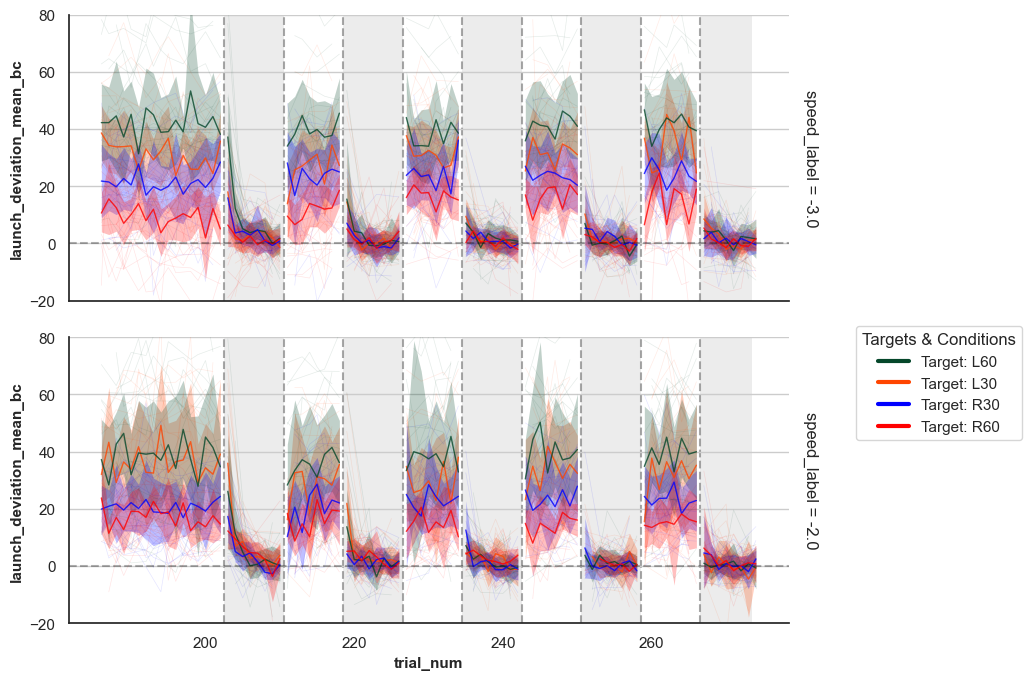

In [21]:
#


from src.plotting import plot_all_trials
plot_all_trials(df_c, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_deviation_mean_bc', # launch_deviation_mean_bc
                     x_col='trial_num',                
                     vertical_list=[],
                     hit_col='target_hit',
                     ref_range_col=None,
                     no_connect_col=['phase','water_speed_binary'],
                     context='notebook', 
                     transition_col='water_speed_binary', 
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-20,80),
                     show_zero_line=True
                    )         

hit min None
hit max None


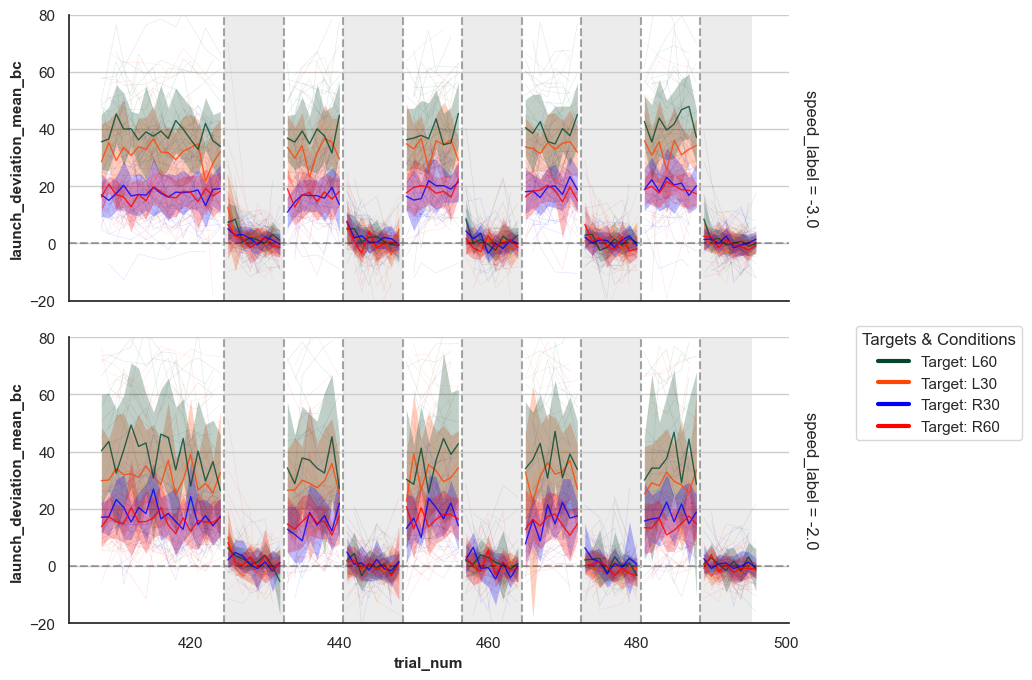

In [41]:
df_t2 = df_bc[df_bc['phase'] == 'training_2']
max_trials = df_t2['trial_num'].max()
# grab last 8 trials of t2 
df_t2_last16 = df_t2[df_t2['trial_num'] >= max_trials - 16]

df_c2 = pd.concat([df_t2_last16, df_w2]) # df_w2_early



from src.plotting import plot_all_trials
plot_all_trials(df_c2, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_deviation_mean_bc', # launch_deviation_mean_bc
                     x_col='trial_num',                
                     vertical_list=[],
                     hit_col='target_hit',
                     ref_range_col=None,
                     no_connect_col=['phase','water_speed_binary'],
                     context='notebook', 
                     transition_col='water_speed_binary', 
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-20,80),
                     show_zero_line=True
                    )         

first trial

washout 1

In [40]:

# label key transition trials of interest (start trial of block)
trials = np.array([1, 9, 17, 25, 33])

# mask to check 
# df_w1['keep_trial'] = df_w1['phase_target_trial_num'].isin(trials)

# drop false 'keep_trial' rows
# df_w1_kept = df_w1[df_w1['keep_trial'] == True]





test = df_w1.groupby(['trial_num','target_x_label','water_speed_m_s','speed_label'])['launch_deviation_mean_bc'].mean()

file_path_t = f"..\\data\\dual_generalization\\test.csv"

test.to_csv(file_path_t, index=True)



# from src.plotting import plot_slopes
# plot_slopes(df_w1_kept,
#                          x_col='phase_target_trial_num',
#                          y_col='launch_deviation_mean_bc',
#                          hue_var='target_x_label', 
#                          ref_range_col='launch_deviation',
#                          facet_col='target_x_label',
#                          facet_row= 'speed_label',
#                          y_lim = (-50,25)
#                             )



C:\Users\jacob\AppData\Local\Temp\ipykernel_5976\3420907272.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test = df_w1.groupby(['trial_num','target_x_label','water_speed_m_s','speed_label'])['launch_deviation_mean_bc'].mean()


In [29]:
df_w1 = df_bc[df_bc['phase'] == 'washout_1'].copy()

washout_1 = df_w1.groupby(['trial_num','target_x_label','water_speed_m_s','speed_label'])['launch_deviation_mean_bc'].mean()

file_path_w1 = f"..\\data\\dual_generalization\\washout_1.csv"

washout_1.to_csv(file_path_w1, index=True)

C:\Users\jacob\AppData\Local\Temp\ipykernel_22464\1423124927.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  washout_1 = df_w1.groupby(['trial_num','target_x_label','water_speed_m_s','speed_label'])['launch_deviation_mean_bc'].mean()


In [7]:
df_w2 = df_bc[df_bc['phase'] == 'washout_2'].copy()

washout_2 = df_w2.groupby(['trial_num','target_x_label','water_speed_m_s','speed_label'])['launch_deviation_mean_bc'].mean()

file_path_w2 = f"..\\data\\dual_generalization\\washout_2.csv"

washout_2.to_csv(file_path_w2, index=True)

NameError: name 'df_bc' is not defined

In [5]:
def solve_target_angle_span(
    target_vx = np.array([-60.0, -30.0, 30.0, 60.0]),
    target_vz = np.array([140.0, 140.0, 140.0, 140.0]),
    ball_diameter = 10.0,
    target_diameter = 7.5
):
    effective_diameter = ball_diameter + target_diameter

    # distance from origin to target centre
    distance = np.sqrt(target_vx**2 + target_vz**2)

    # solve for angular diameter:
    angular_diameter_deg = np.degrees(2*np.arctan(effective_diameter/(2*distance)))

    return angular_diameter_deg
    

    
solve_target_angle_span()

array([6.57566426, 6.99429527, 6.99429527, 6.57566426])

first trial + 1

C:\Users\jacob\AppData\Local\Temp\ipykernel_25376\3578456376.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_w1_kept.groupby(['phase_target_trial_num','target_x_label'])['launch_deviation_mean_bc'].mean())


phase_target_trial_num  target_x_label
2                       L60              -3.374094
                        L30              -3.902323
                        R30              -3.708551
                        R60              -3.080593
10                      L60              -1.765875
                        L30              -0.607208
                        R30              -0.542188
                        R60              -1.993675
18                      L60              -1.970421
                        L30              -1.357142
                        R30              -2.025949
                        R60              -1.524069
26                      L60              -0.932341
                        L30              -0.489879
                        R30              -0.757348
                        R60              -0.963132
34                      L60              -1.393206
                        L30              -0.796650
                        R30              -0

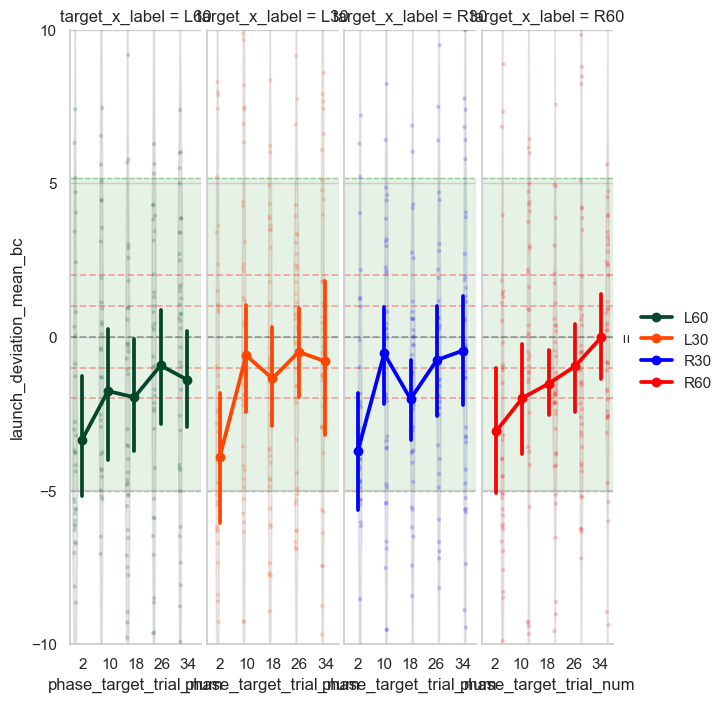

In [63]:

# look at second trial per target
trials_p1 = trials + 1


# mask to check 
df_w1['keep_trial'] = df_w1['phase_target_trial_num'].isin(trials_p1)

# drop false 'keep_trial' rows
df_w1_kept = df_w1[df_w1['keep_trial'] == True]

# results
print(df_w1_kept.groupby(['phase_target_trial_num','target_x_label'])['launch_deviation_mean_bc'].mean())


from src.plotting import plot_slopes
plot_slopes(df_w1_kept,
                         x_col='phase_target_trial_num',
                         y_col='launch_deviation_mean_bc',
                         hue_var='target_x_label', 
                         ref_range_col='signed_euclidean_cm',
                         facet_col='target_x_label',
                         facet_row= None,
                         y_lim = (-10,10)
                            )



Early (first 16 trials, purple) vs Late (Last 16 trials, orange) of *Training Phase 1 (T1)*

C:\Users\jacob\water_current_MA\src\early_late_exposure.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby(group_cols + [phase_col])


0
1


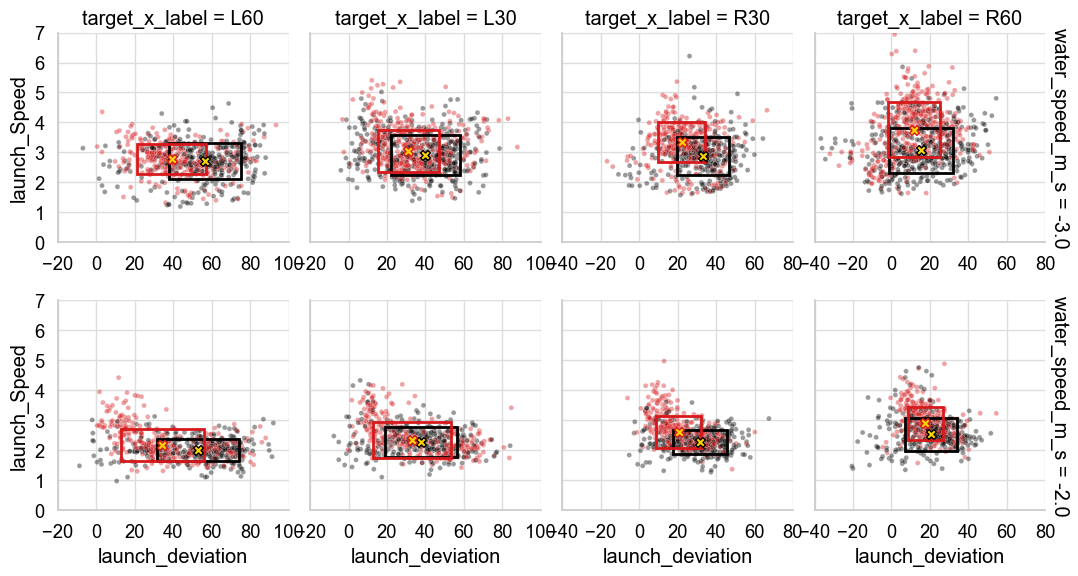

In [84]:
from src.early_late_exposure import early_late_phase_new

early_late_phase_df_16_t1 = early_late_phase_new(df = df_bc,
                 group_cols = ['ppid_full','set_order','target_x_label','speed_label'],
                 phase_col = 'phase',
                 phases_to_keep=['training_1'],
                 trial_col = 'phase_target_trial_num',
                 n_trials = 16
                ).copy()

from src.plotting import plot_heatmap




plot_heatmap(early_late_phase_df_16_t1,
                     x_col='launch_deviation',
                     y_col='launch_Speed',
                     colour_col='trial_set',
                     mode='correlation', 
                     facet_col='target_x_label',
                     facet_row='water_speed_m_s',
                     x_col_title = 'Launch Deviation (deg)',
                     y_col_title = 'Launch Speed (m/s)',
                     show_median_sd=True)

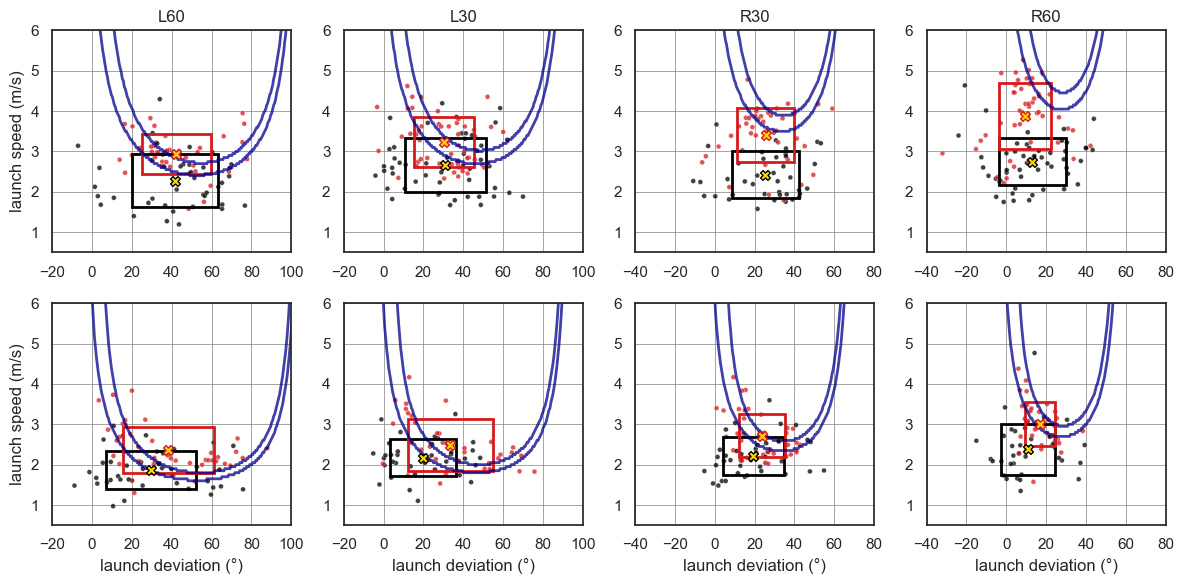

In [31]:
from src.plotting import plot_solution_space_heatmap

plot_solution_space_heatmap(early_late_phase_df_2_t1,
                            x_col='launch_deviation',
                            y_col='launch_Speed',
                            water_col='water_speed_m_s',
                            target_col='target_x_label',
                            colour_col='trial_set',
                            show_centre_sd=True
                           
                           )

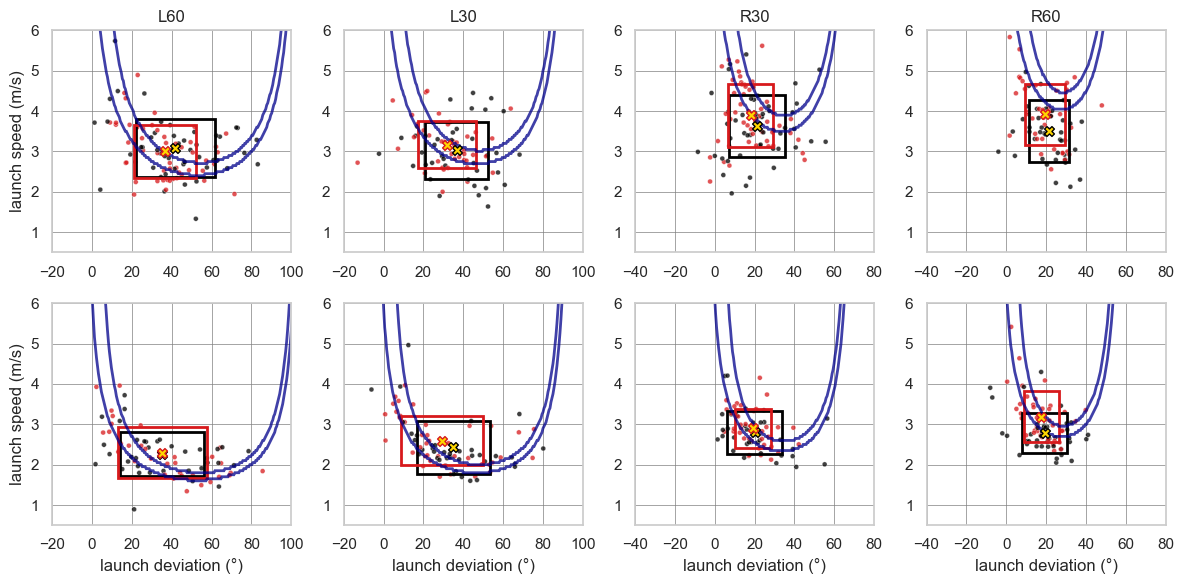

In [23]:
from src.plotting import plot_solution_space_heatmap

plot_solution_space_heatmap(early_late_phase_df_2_t2,
                            x_col='launch_deviation',
                            y_col='launch_Speed',
                            water_col='water_speed_m_s',
                            target_col='target_x_label',
                            colour_col='trial_set',
                            show_centre_sd=True
                           
                           )

In [109]:
# early_late_phase_df_16_t1


median_speed_df = early_late_phase_df_16_t1.groupby(['water_speed_m_s','target_x_label','trial_set'], observed=True)[['launch_Speed']].agg(['median','std'])
median_dev_df = early_late_phase_df_16_t1.groupby(['water_speed_m_s','target_x_label','trial_set'], observed=True)[['launch_deviation']].agg(['median','std'])

median_parameter_df = pd.merge(median_speed_df, median_dev_df, on=['water_speed_m_s','target_x_label','trial_set'])

In [121]:
median_parameter_df['launch_deviation']

median        std
water_speed_m_s target_x_label trial_set                      
-3.0            L60            early      56.466536  18.929285
                               late       39.178616  17.879692
                L30            early      39.956222  18.082877
                               late       31.120637  15.762547
                R30            early      33.326768  13.476745
                               late       22.106138  12.256209
                R60            early      15.502624  16.610410
                               late       11.746139  13.752099
-2.0            L60            early      52.735666  21.266473
                               late       34.286916  21.665281
                L30            early      37.677202  18.543618
                               late       33.117282  20.313929
                R30            early      31.691968  13.906763
                               late       20.521863  11.768195
                R60            early      20.566059  13.554664
                               late       17.719809   9.286383

In [97]:
median_speed_df

launch_Speed
water_speed_m_s target_x_label trial_set              
-3.0            L60            early          2.711970
                               late           2.766366
                L30            early          2.912033
                               late           3.050318
                R30            early          2.894544
                               late           3.351882
                R60            early          3.067241
                               late           3.761720
-2.0            L60            early          2.014403
                               late           2.170940
                L30            early          2.275953
                               late           2.341350
                R30            early          2.268340
                               late           2.598765
                R60            early          2.535389
                               late           2.894780

In [21]:
# save csv
file_path_E_L_16 = f"..\\data\\dual_generalization\\early_late_phase_df_16_t1.csv"
early_late_phase_df_16_t1.to_csv(file_path_E_L_16, index=True)

Early (first 16 trials, purple) vs Late (Last 16 trials, orange) of *Training Phase 2 (T2)*

C:\Users\jacob\water_current_MA\src\early_late_exposure.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby(group_cols + [phase_col])


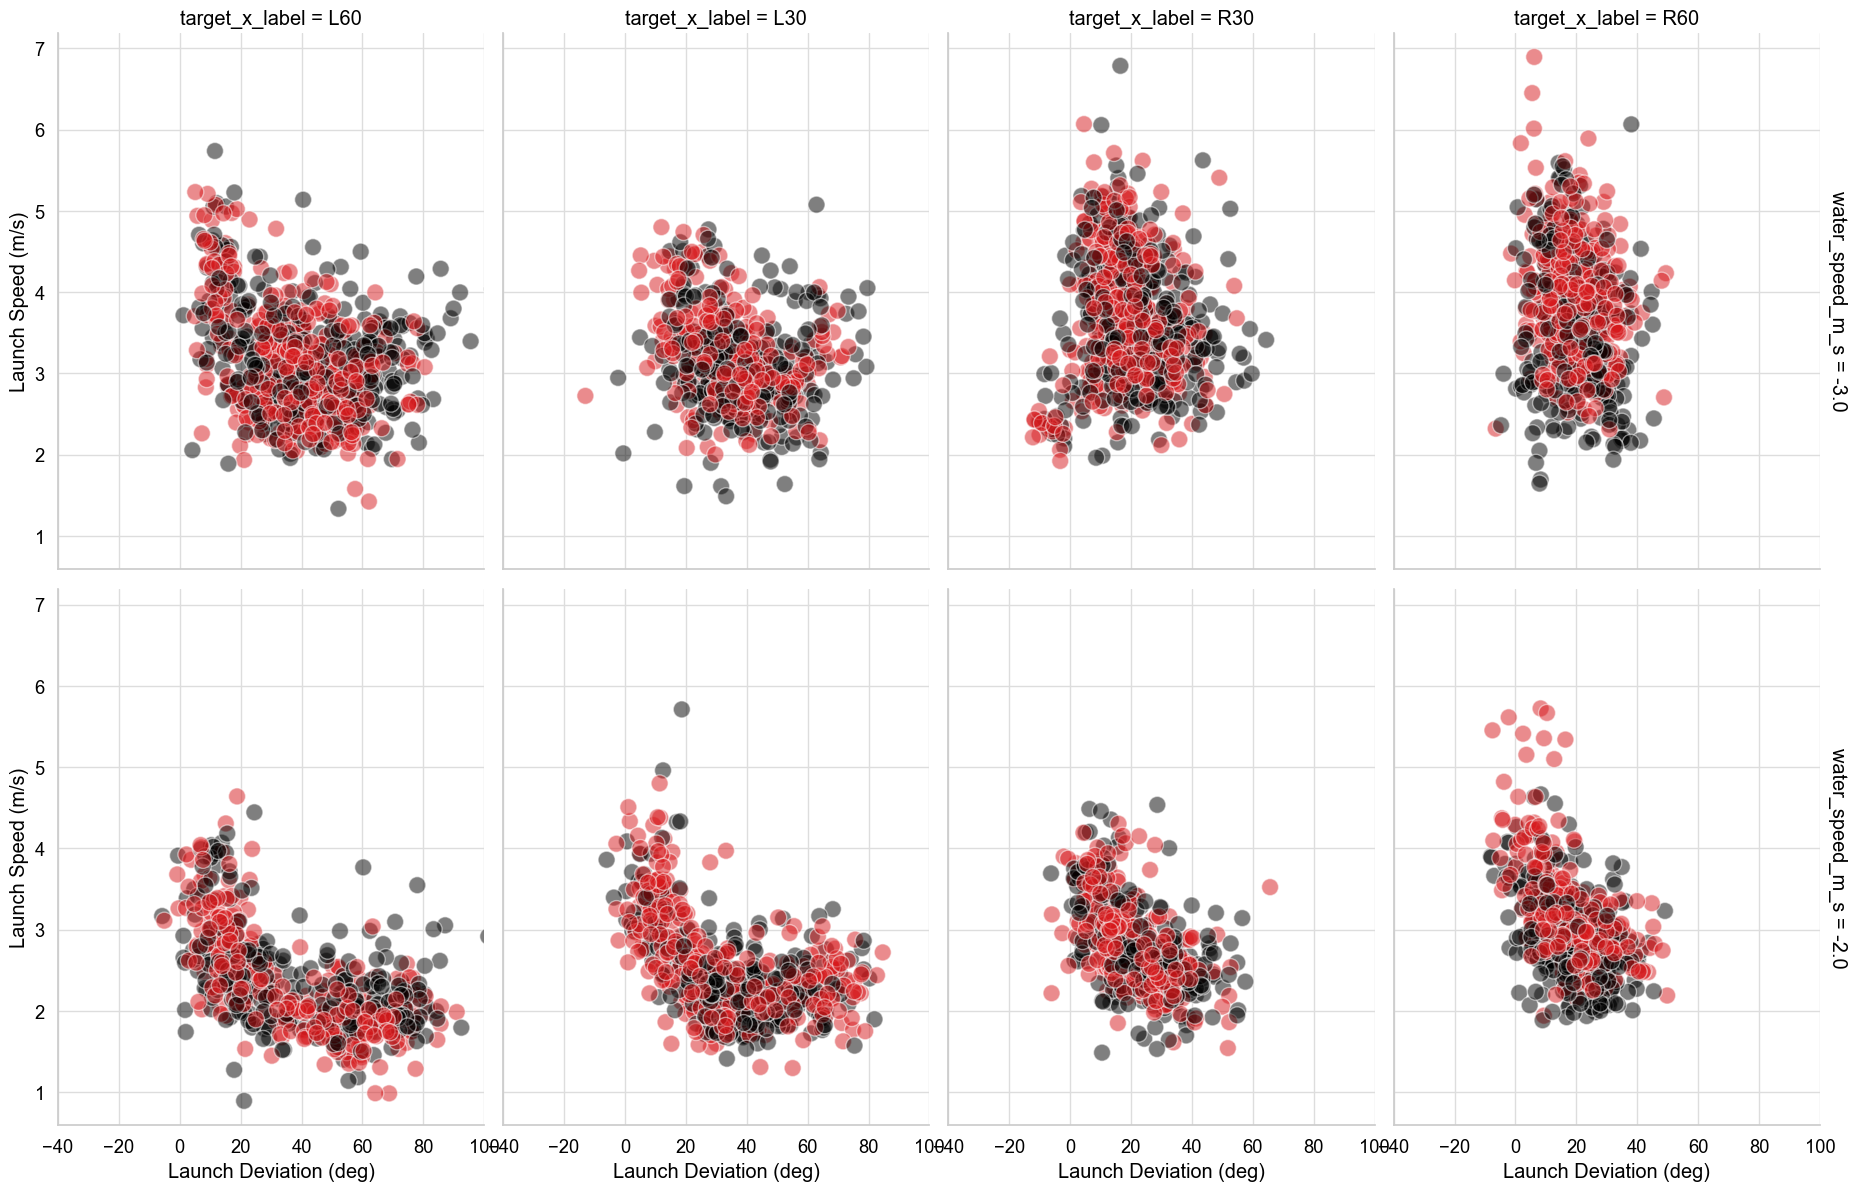

In [75]:
from src.early_late_exposure import early_late_phase_new

early_late_phase_df_16_t2 = early_late_phase_new(df = df_bc,
                 group_cols = ['ppid_full','set_order','target_x_label','speed_label'],
                 phase_col = 'phase',
                 phases_to_keep=['training_2'],
                 trial_col = 'phase_target_trial_num',
                 n_trials = 16
                ).copy()

from src.plotting import plot_heatmap

plot_heatmap(early_late_phase_df_16_t2,
                     x_col = 'launch_deviation',
                     y_col='launch_Speed',
                     colour_col='trial_set',
                     mode='correlation', 
                     facet_col='target_x_label',
                     facet_row='water_speed_m_s',
                     dark=False,
                     x_col_title = 'Launch Deviation (deg)',
                     y_col_title = 'Launch Speed (m/s)')
